In [39]:
# 1. Imports

%matplotlib inline  

import os  
from datetime import datetime  
import colorsys  # RGB↔HSV conversions for the required CSV metadata columns

import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt  
from tqdm.auto import tqdm  

from IPython.display import display, clear_output  

from scipy.ndimage import gaussian_filter, distance_transform_edt  

import zarr  # Export stimulus + response arrays for MLR/RF/CNN workflows
import zarr.codecs  

In [3]:
# 2. Parameters
LUT = {
    "wavelength_nm": np.arange(390, 701, 5),
    "mac_od": np.array([0.04533,0.06489,0.0868,0.112,0.1365,0.1631,0.1981,0.2345,0.2618,0.2772,0.2884,0.308,0.3332,0.3486,0.35,0.3269,0.2996,0.2842,0.2786,0.2772,0.2688,0.2485,0.2093,0.1652,0.1211,0.0812,0.0525,0.0329,0.0175,0.00929,0.00459,0.00166,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
    "lens_od": np.array([2.5122,2.1306,1.7649,1.4257,1.13738,0.9063,0.72398,0.59572,0.4876,0.4081,0.34132,0.29998,0.26288,0.2438,0.2279,0.21306,0.20458,0.19292,0.18338,0.1749,0.16748,0.16006,0.1537,0.14628,0.1378,0.12932,0.12296,0.1166,0.11024,0.10494,0.09858,0.09222,0.08586,0.0795,0.0742,0.06784,0.06148,0.05512,0.04876,0.04346,0.03812,0.03286,0.02968,0.02544,0.02226,0.01908,0.01696,0.01484,0.01166,0.00848,0.0053,0.00424,0.00318,0.00106,0,0,0,0,0,0,0,0,0]),
    "cone_ext_parameters": np.array([0.417050601,0.002072146099,0.0001638878333,-1.922880605,-16.05774461,0.001575425685,0.0000511375521,0.00157980964,0.00006584275242,0.00006684015221,0.002310441807,0.00007313131766,0.00001862685404,0.002008124081,0.00005407174451,0.00000514735556,0.001455412882,0.00004217635152,4.80E-06,0.001809022392,0.00003866766734,2.99E-05,0.001757314922,0.00001473437751,1.51E-05,0.35000001,0.1248091545,0.02274730785,0.0009731002994], dtype=float),
    "input_photopigment_peak_s": 419,
    "input_photopigment_peak_m": 530,
    "input_photopigment_peak_l": 557.25,
    "input_ODmax_s": 0.35,
    "input_ODmax_m": 0.3,
    "input_ODmax_l": 0.3,
    "primary_r": np.array([0.15,0.00,0.00,0.00,0.16,0.67,2.27,4.65,9.27,14.71,20.17,28.36,32.79,26.87,15.82,8.33,5.12,3.28,2.11,1.45,1.00,0.95,0.93,0.89,1.11,1.33,1.43,1.65,1.54,1.37,1.14,1.07,0.77,0.82,0.72,1.13,3.86,20.89,83.73,217.09,406.93,617.30,767.04,841.61,880.56,874.64,833.56,786.86,735.62,683.48,626.69,553.89,502.62,469.58,427.00,386.31,342.35,305.56,262.91,227.58,199.75,179.59,161.84]),
    "primary_g": np.array([0.00,0.05,0.00,0.00,0.00,0.00,0.12,0.55,1.63,4.60,10.72,23.07,37.52,47.36,55.72,71.12,99.87,123.43,131.23,127.34,142.58,174.86,227.38,285.70,388.61,508.82,621.44,644.47,712.30,760.29,789.32,789.25,751.83,742.14,687.43,630.10,573.19,490.28,411.33,330.16,246.74,173.14,111.25,64.28,34.18,16.73,8.20,4.39,2.64,1.83,1.34,1.16,0.95,0.78,0.69,0.72,0.80,1.00,1.15,1.54,2.07,2.67,3.44]),
    "primary_b": np.array([0.21,0.13,0.00,0.00,0.89,4.87,16.55,46.70,118.50,249.45,450.46,819.32,1234.87,1291.28,944.04,599.84,417.24,281.30,181.82,121.72,97.11,91.72,89.71,87.65,86.12,79.72,66.47,48.76,40.28,33.82,29.70,23.65,17.67,12.50,8.21,5.86,4.69,4.07,3.65,3.21,2.82,2.50,2.20,1.87,1.82,1.72,1.90,2.13,2.45,2.96,3.63,4.32,5.13,5.98,6.58,7.01,6.84,6.51,5.91,5.18,4.75,4.65,4.22]),
    "sigma_center": 0.025,
    "sigma_surround": 0.165,
    "surround_ratio_lm": np.array([1/2, 1/2]),
    "surround_ratio_lms": np.array([1/3, 1/3, 1/3]),
    "center_inhib_ratio_lm": np.array([0.5, 0.5]),
}

n = len(LUT["wavelength_nm"])
keys = ["mac_od", "lens_od", "primary_r", "primary_g", "primary_b"]
for k in keys:
    if len(LUT[k]) != n:
        raise ValueError(f"{k} has {len(LUT[k])} entries, expected {n}")
                     
    

In [4]:
# 3. Carroll cone extinction equation
ext_p = LUT["cone_ext_parameters"]
letters = list("ABCDEFGHIJKLMNOPQRSTUVWXY")
p = dict(zip(letters, ext_p[:25]))

def _gauss(x, mu, sigma):
    return (1.0/np.sqrt(2.0*np.pi))*np.exp(-0.5*((x-mu)/sigma)**2)

def cone_log_extinction(wavelength_nm, lambda_max_nm, p, ref_nm=558.5):
    shift = np.log10(1.0/lambda_max_nm)-np.log10(1.0/ref_nm)
    x = 10.0**(np.log10(1.0/wavelength_nm)-shift)
    part1_inside = (-p["E"]+p["E"]*np.tanh(-((x-p["F"])/p["G"])))
    part1 = np.log10(part1_inside)+p["D"]+p["A"]*np.tanh(-((x-p["B"])/p["C"]))
    part2 = (
        -(p["J"]/p["I"])*_gauss(x,p["H"],p["I"])
        -(p["M"]/p["L"])*_gauss(x,p["K"],p["L"])
        -(p["P"]/p["O"])*_gauss(x,p["N"],p["O"])
        +(p["S"]/p["R"])*_gauss(x,p["Q"],p["R"])
        +(p["V"]/p["U"])*_gauss(x,p["T"],p["U"])/10.0
        +(p["Y"]/p["X"])*_gauss(x,p["W"],p["X"])/100.0
    )
    whole = part1+part2
    return whole
           

In [5]:
# 4. Compute cone extinction arrays
log_ext_s = cone_log_extinction(LUT["wavelength_nm"], LUT["input_photopigment_peak_s"], p)
log_ext_m = cone_log_extinction(LUT["wavelength_nm"], LUT["input_photopigment_peak_m"], p)
log_ext_l = cone_log_extinction(LUT["wavelength_nm"], LUT["input_photopigment_peak_l"], p)


In [12]:
# 5. effective cone spectral sensitivity with optical desity  
def apply_OD(cone_log_extinction, input_ODmax, mac_od, lens_od):
    cone_linear_extinction = 10.0**cone_log_extinction
    numerator = 1.0-10.0**(-(cone_linear_extinction*input_ODmax))
    denominator = 1.0 - 10.0**(-input_ODmax)
    step1 = np.log10(numerator/denominator)-lens_od-mac_od
    final = 10.0**(step1+2)
    return final

In [13]:
# 6. compute effective cone spectral sensitivity with optical desity
ext_s = apply_OD(log_ext_s, LUT["input_ODmax_s"], LUT["mac_od"], LUT["lens_od"])
ext_m = apply_OD(log_ext_m, LUT["input_ODmax_m"], LUT["mac_od"], LUT["lens_od"])
ext_l = apply_OD(log_ext_l, LUT["input_ODmax_l"], LUT["mac_od"], LUT["lens_od"])
ext_surround_lm = LUT["surround_ratio_lm"][0]*ext_m+LUT["surround_ratio_lm"][1]*ext_l
ext_surround_lms = (LUT["surround_ratio_lms"][0]*ext_s+LUT["surround_ratio_lms"][1]*ext_m
                    +LUT["surround_ratio_lms"][2]*ext_l)
ext_center_inhib_lm = (LUT["center_inhib_ratio_lm"][0]*ext_m+LUT["center_inhib_ratio_lm"][1]*ext_l)

In [14]:
# 7. compute RGB primary quanta to white light [1,1,1] 
white = np.array([1.0,1.0,1.0])
yellow = np.array([1.0,1.0,0.0])
primaries = np.stack([LUT["primary_r"],LUT["primary_g"],LUT["primary_b"]], axis=1)
primary_white = (white*primaries).sum(axis=1)
primary_yellow = (yellow*primaries).sum(axis=1)
total_quanta_white = primary_white.sum()
total_quanta_yellow = primary_yellow.sum()


In [15]:
# 8. Find scalar to equalize total quantal response of L- and M-center to LM-surround

response_white_lm = np.sum(ext_surround_lm*primary_white)
response_white_l = np.sum(ext_l*primary_white)
response_white_m = np.sum(ext_m*primary_white)
response_white_s = np.sum(ext_s*primary_white) 
response_white_lms = np.sum(ext_surround_lms*primary_white) 
response_white_inhib_lm = np.sum(ext_center_inhib_lm*primary_white)

scalar_l = response_white_lm/response_white_l
scalar_m = response_white_lm/response_white_m
scalar_s = response_white_lm/response_white_s 
scalar_lms = response_white_lm/response_white_lms 
scalar_s_inhib_lm = response_white_inhib_lm/response_white_s 

response_yellow_lm = np.sum(ext_surround_lm*primary_yellow)
response_yellow_l = np.sum(ext_l*primary_yellow)
response_yellow_m = np.sum(ext_m*primary_yellow)


In [16]:
# 9. Build 2D gaussian (and DoGs) receptive fields
radius = 1.05 # degrees
dx = 0.005 # pixels per degree
x = np.arange(-radius, radius+dx, dx)
X,Y = np.meshgrid(x,x)

# spatial kernal 
amp_center = 1.0
amp_surround = amp_center*(LUT["sigma_center"]**2)/(LUT["sigma_surround"]**2)

def gaussian_2D(X,Y,amp,sigma):
    return amp*np.exp(-(X**2+Y**2)/(2*sigma**2))

gaussian_center = gaussian_2D(X,Y,amp_center,LUT["sigma_center"])
gaussian_surround = gaussian_2D(X,Y,amp_surround,LUT["sigma_surround"])

rf_on = gaussian_center-gaussian_surround
rf_off = -rf_on

# sanity check
integral_center = gaussian_center.sum()*dx*dx
integral_surround = gaussian_surround.sum()*dx*dx
print(integral_center, integral_surround, integral_center/integral_surround)
print(scalar_l*response_white_l, response_white_lm)
print(scalar_m*response_white_m, response_white_lm)
print(scalar_s*response_white_s, scalar_lms*response_white_lms) 
print(scalar_s_inhib_lm*response_white_s, response_white_inhib_lm) 

0.00392699081698741 0.003926990815587745 1.0000000003564218
1155423.701290184 1155423.701290184
1155423.701290184 1155423.701290184
1155423.701290184 1155423.701290184
1155423.701290184 1155423.701290184


In [17]:
# 10. check response under full white [1,1,1], or yellow [1,1,0], compute uniform field responses
dog_response_l_white = ((scalar_l*response_white_l)*gaussian_center.sum()*dx*dx-
                        (response_white_lm)*gaussian_surround.sum()*dx*dx)
dog_response_m_white = ((scalar_m*response_white_m)*gaussian_center.sum()*dx*dx-
                        (response_white_lm)*gaussian_surround.sum()*dx*dx)
dog_response_h2_white = ((scalar_s*response_white_s)*gaussian_center.sum()*dx*dx-
                         (scalar_lms*response_white_lms)*gaussian_surround.sum()*dx*dx)
dog_response_s_white = ((scalar_s_inhib_lm*response_white_s)*gaussian_center.sum()*dx*dx-
                        (response_white_inhib_lm)*gaussian_center.sum()*dx*dx) # Adding s-RGC model
dog_response_l_yellow = ((scalar_l*response_yellow_l)*gaussian_center.sum()*dx*dx-
                         (response_yellow_lm)*gaussian_surround.sum()*dx*dx)
dog_response_m_yellow = ((scalar_m*response_yellow_m)*gaussian_center.sum()*dx*dx-
                         (response_yellow_lm)*gaussian_surround.sum()*dx*dx)

print("L center under white light: ", (scalar_l*response_white_l)*gaussian_center.sum()*dx*dx)
print("M center under white light: ", (scalar_m*response_white_m)*gaussian_center.sum()*dx*dx)
print("S center under white light: ", (scalar_s*response_white_s)*gaussian_center.sum()*dx*dx)
print("surround under white light: ", (response_white_lm)*gaussian_surround.sum()*dx*dx)
print("LM center under white light: ", (response_white_inhib_lm)*gaussian_center.sum()*dx*dx)
print("DoG under white light (L-center, M-center, H2, S-center): ", dog_response_l_white, dog_response_m_white, dog_response_h2_white, dog_response_s_white)
print("L center under yellow light: ", (scalar_l*response_yellow_l)*gaussian_center.sum()*dx*dx)
print("M center under yellow light: ", (scalar_m*response_yellow_m)*gaussian_center.sum()*dx*dx)
print("surround under yellow light: ", (response_yellow_lm)*gaussian_surround.sum()*dx*dx)
print("DoG under yellow light (L-center, M-center): ", dog_response_l_yellow, dog_response_m_yellow)
print("Percentage of center, DoG under yellow light (L-center, M-center): ", 
      dog_response_l_yellow/((scalar_l*response_yellow_l)*gaussian_center.sum()*dx*dx), 
      dog_response_m_yellow/((scalar_m*response_yellow_m)*gaussian_center.sum()*dx*dx))


L center under white light:  4537.338264696156
M center under white light:  4537.338264696156
S center under white light:  4537.338264696156
surround under white light:  4537.338263078949
LM center under white light:  4537.338264696156
DoG under white light (L-center, M-center, H2, S-center):  1.617207090021111e-06 1.617207090021111e-06 1.617207090021111e-06 0.0
L center under yellow light:  4234.125064542216
M center under yellow light:  3980.384448817143
surround under yellow light:  4124.127673848555
DoG under yellow light (L-center, M-center):  109.99739069366115 -143.74322503141184
Percentage of center, DoG under yellow light (L-center, M-center):  0.025978776965000634 -0.0361128998667775


In [18]:
# 11. FFT 2D convolution
def fft_2d(image, kernel, pad_mode="reflect"):
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    Ih,Iw = image.shape
    Kh,Kw = kernel.shape
    pady = Kh//2
    padx = Kw//2
    imgpad = np.pad(image, ((pady,pady), (padx,padx)),mode=pad_mode)
    Ph,Pw = imgpad.shape
    out_shape = (Ph+Kh-1, Pw+Kw-1)
    y = np.fft.ifft2(np.fft.fft2(imgpad, out_shape)*np.fft.fft2(kernel, out_shape)).real
    r0 = Kh//2
    c0 = Kw//2
    convpad = y[r0:r0+Ph, c0:c0+Pw]
    return convpad[pady:pady+Ih, padx:padx+Iw]


In [19]:
# 12. Helper functions: build RGB circle stimuli + run the mRGC model   

# =========================
# USER SETTINGS (edit here)
# =========================
IMAGE_SIZE_PX = 1000        # User sets image size (always square)
OBJ_DIAM_RATIO = 0.5        # User sets object diameter / image size (circle)
GRAY_LIGHT_THRESHOLD = 0.5  # Absolute split for gray_l vs gray_d (upper/lower half of 0..1 intensity scale)
GRAY_TOL = 1e-6             # Tolerance for deciding if an RGB is truly grayscale (R≈G≈B)

# --- Fixed luminance rule (Rec.709 only) ---                           # Enforce Rec.709 luma (not adjustable)
REC709_W = np.array([0.2126, 0.7152, 0.0722], dtype=float)             # Rec.709 RGB→luma weights

# --- Simple hue definitions (RGB "unit hues") ---                      
HUE_RGB = {                                                            # Map labels → base RGB vectors
    "gray":   np.array([1.0, 1.0, 1.0], dtype=float),                  # Gray is neutral RGB
    "red":    np.array([1.0, 0.0, 0.0], dtype=float),                  # Red hue
    "green":  np.array([0.0, 1.0, 0.0], dtype=float),                  # Green hue
    "blue":   np.array([0.0, 0.0, 1.0], dtype=float),                  # Blue hue
    "yellow": np.array([1.0, 1.0, 0.0], dtype=float),                  # Yellow hue (R+G)
}

def rec709_luma(rgb):                                                  # Utility for “intensity” reporting in metadata
    rgb = np.asarray(rgb, dtype=float)                                
    return float(np.dot(rgb, REC709_W))                                # Rec.709 luma scalar

def rgb_from_hue_int_sat(hue_rgb, intensity, saturation=1.0):          # One clear RGB constructor for center/background
    """
    Build an RGB color in [0,1] from:
      - hue_rgb: base RGB "hue vector" (e.g., [1,0,0] for red)
      - intensity: brightness/peak value (0..1)
      - saturation: mix between hue and white (0..1). 1=fully saturated, 0=white/gray.
    """
    hue_rgb = np.asarray(hue_rgb, dtype=float)                         # Normalize inputs for safety
    intensity = float(intensity)                                       # Ensure scalar
    saturation = float(saturation)                                     # Ensure scalar
    if not (0.0 <= intensity <= 1.0):                                
        raise ValueError("intensity must be in [0,1]")                 
    if not (0.0 <= saturation <= 1.0):                                
        raise ValueError("saturation must be in [0,1]")                

    mx = float(np.max(hue_rgb))                                        # Normalize hue so max channel is 1
    if mx <= 0.0:                                                      
        raise ValueError("hue_rgb must have a positive max channel")   
    hue_unit = hue_rgb / mx                                            # Max-normalized hue

    rgb_unit = saturation * hue_unit + (1.0 - saturation) * np.ones(3) # Desaturate by mixing toward white
    rgb = intensity * rgb_unit                                         # Apply intensity after desaturation
    return np.clip(rgb, 0.0, 1.0)                                      # eep valid RGB bounds

def rgb_from_label(label, intensity, saturation=1.0):                  # Convenience wrapper for labeled hues
    if label not in HUE_RGB:                                          
        raise ValueError(f"Unknown label '{label}'. Use {list(HUE_RGB)}")  
    return rgb_from_hue_int_sat(HUE_RGB[label], intensity, saturation) # Delegate to the core constructor

def true_label(obj_hue_label, obj_rgb):                               
    """
    Returns one of: gray_l, gray_d, red, green, blue, yellow.

    - Chromatic objects: label is the object's hue label.
    - Gray objects: label is based on ABSOLUTE intensity, split at GRAY_LIGHT_THRESHOLD.
    """
    if obj_hue_label != "gray":                                        # Chromatic objects keep their hue label
        return obj_hue_label                                           

    obj_rgb = np.asarray(obj_rgb, dtype=float)                         # Normalize inputs
    if float(np.max(np.abs(obj_rgb - float(np.mean(obj_rgb))))) > GRAY_TOL:  # Verify true grayscale (R≈G≈B)
        raise ValueError("obj_hue_label='gray' but obj_rgb is not grayscale")  

    obj_int = rec709_luma(obj_rgb)                                     # Absolute intensity measure (Rec.709 luma)
    return "gray_l" if obj_int >= GRAY_LIGHT_THRESHOLD else "gray_d"    # Absolute light/dark split

def rgb_to_hsv01(rgb):                                                 # HSV needed for metadata CSV
    r, g, b = [float(x) for x in np.clip(rgb, 0.0, 1.0)]                
    h, s, v = colorsys.rgb_to_hsv(r, g, b)                              
    return np.array([h, s, v], dtype=float)                             

def make_circle_stimulus(bg_rgb, obj_rgb, size_px=IMAGE_SIZE_PX, obj_diam_ratio=OBJ_DIAM_RATIO):  # Defaults come from user settings above
    """
    Returns an RGB image of shape (size_px, size_px, 3) with:
      - background color bg_rgb everywhere
      - a centered circular object of diameter = obj_diam_ratio * size_px
    """
    size_px = int(size_px)                                             
    if size_px <= 0:                                                   
        raise ValueError("size_px must be positive")                    
    obj_diam_ratio = float(obj_diam_ratio)                              
    if not (0.0 < obj_diam_ratio <= 1.0):                              
        raise ValueError("obj_diam_ratio must be in (0,1]")            

    bg_rgb = np.asarray(bg_rgb, dtype=float)                            # Normalize colors
    obj_rgb = np.asarray(obj_rgb, dtype=float)                         

    img = np.broadcast_to(bg_rgb, (size_px, size_px, 3)).copy()         # Fill background
    cy = cx = size_px // 2                                              # Center pixel
    radius = 0.5 * obj_diam_ratio * size_px                             # Radius from diameter ratio

    yy, xx = np.ogrid[:size_px, :size_px]                               # Memory-efficient coordinate grids
    mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2               # Circle mask
    img[mask] = obj_rgb                                                 # Paint object
    return img                                                          # Return RGB stimulus

# --- RGB→“cone drive” weights (precompute once) ---                     
PRIMARIES_RGB = np.stack([LUT["primary_r"], LUT["primary_g"], LUT["primary_b"]], axis=1)  

rgb2q_L = ext_l @ PRIMARIES_RGB                                         # L-cone RGB→quanta weights
rgb2q_M = ext_m @ PRIMARIES_RGB                                         # M-cone RGB→quanta weights
rgb2q_S = ext_s @ PRIMARIES_RGB                                         # S-cone RGB→quanta weights
rgb2q_LM_sur = ext_surround_lm @ PRIMARIES_RGB                           # LM surround mixture RGB→quanta
rgb2q_LMS_sur = ext_surround_lms @ PRIMARIES_RGB                          # LMS surround mixture (H2) RGB→quanta
rgb2q_LM_inhib_center = ext_center_inhib_lm @ PRIMARIES_RGB              # LM inhibitory center (for s_on) RGB→quanta

def rgb_image_to_drive(img_rgb, rgb2q):                                 
    img_rgb = np.asarray(img_rgb, dtype=float)                          
    return (img_rgb[..., 0] * rgb2q[0] +                                # Per-pixel linear combo
            img_rgb[..., 1] * rgb2q[1] +
            img_rgb[..., 2] * rgb2q[2])

def run_mrgc_model(img_rgb):                                            
    """
    Given an RGB stimulus image (H,W,3), returns a dict of response maps.
    Uses the already-built spectral model (ext_*) and spatial RF kernels (gaussian_*).
    """
    drive_L = rgb_image_to_drive(img_rgb, rgb2q_L)                       # L-cone drive image
    drive_M = rgb_image_to_drive(img_rgb, rgb2q_M)                       # M-cone drive image
    drive_S = rgb_image_to_drive(img_rgb, rgb2q_S)                       # S-cone drive image

    drive_LM_sur = rgb_image_to_drive(img_rgb, rgb2q_LM_sur)             # LM surround drive image
    drive_LMS_sur = rgb_image_to_drive(img_rgb, rgb2q_LMS_sur)           # LMS surround drive image (H2 variant)
    drive_LM_inhib = rgb_image_to_drive(img_rgb, rgb2q_LM_inhib_center)  # LM inhibitory center drive (for s_on)

    center_L = fft_2d(drive_L, gaussian_center)                          # Center-filtered L drive
    center_M = fft_2d(drive_M, gaussian_center)                          # Center-filtered M drive
    center_S = fft_2d(drive_S, gaussian_center)                          # Center-filtered S drive

    surround_LM = fft_2d(drive_LM_sur, gaussian_surround)                # Surround-filtered LM drive
    surround_LMS = fft_2d(drive_LMS_sur, gaussian_surround)              # Surround-filtered LMS drive
    inhib_center_LM = fft_2d(drive_LM_inhib, gaussian_center)            # Inhibitory term uses center kernel

    l_on = scalar_l * center_L - surround_LM                             # Standard L-center ON mRGC
    m_on = scalar_m * center_M - surround_LM                             # Standard M-center ON mRGC

    l_off = -l_on                                                        # OFF is sign-flip
    m_off = -m_on                                                        # OFF is sign-flip

    l_h2_on = (scalar_l * center_L + scalar_lms * surround_LMS) - (scalar_s * center_S + surround_LM)  # H2 variant
    m_h2_on = (scalar_m * center_M + scalar_lms * surround_LMS) - (scalar_s * center_S + surround_LM)  # H2 variant

    l_h2_off = -l_h2_on                                                  # OFF is sign-flip
    m_h2_off = -m_h2_on                                                  # OFF is sign-flip

    s_on = (scalar_s_inhib_lm * center_S) - inhib_center_LM              # S-center ON with LM inhibitory center

    return {                                                             # Single, explicit output dict
        "l_on": l_on, "l_off": l_off,
        "m_on": m_on, "m_off": m_off,
        "l_h2_on": l_h2_on, "m_h2_on": m_h2_on,
        "l_h2_off": l_h2_off, "m_h2_off": m_h2_off,
        "s_on": s_on,
    }

RESPONSE_KEYS = [                                                       # One canonical key order for export and ML pipelines
    "l_on", "l_off", "m_on", "m_off",
    "l_h2_on", "m_h2_on", "l_h2_off", "m_h2_off",
    "s_on",
]

In [23]:
# 13. Stimulus settings + deduplicated preview counts (no images generated)  

# =========================                                                  
# USER SETTINGS (edit here)                                                
# =========================                                         

# --- Object (center circle) settings ---                                   
OBJ_GRAY_N = 2                                                               # Number of gray center intensities
OBJ_GRAY_MIN = 0.3                                                           # Gray intensity minimum
OBJ_GRAY_MAX = 0.7                                                           # Gray intensity maximum

OBJ_CHROM_N_INT = 2                                                          # Number of chromatic intensities per hue
OBJ_CHROM_INT_MIN = 0.3                                                      # Chromatic intensity minimum
OBJ_CHROM_INT_MAX = 0.7                                                      # Chromatic intensity maximum

OBJ_CHROM_N_SAT = 2                                                          # Number of chromatic saturations per hue
OBJ_CHROM_SAT_MIN = 0.3                                                      # Chromatic saturation minimum
OBJ_CHROM_SAT_MAX = 0.7                                                      # Chromatic saturation maximum

# --- Background settings (deltas relative to the center object's params) ---# Background stimulus settings
BG_GRAY_N_INT = 2                                                            # Number of gray background intensities per center
BG_GRAY_DELTA_INT_MIN = -0.4                                                 # Gray-background minimum intensity delta
BG_GRAY_DELTA_INT_MAX = 0.4                                                  # Gray-background maximum intensity delta

BG_CHROM_N_INT = 2                                                           # Number of chromatic background intensities per center
BG_CHROM_DELTA_INT_MIN = -0.2                                                # Chromatic-background minimum intensity delta
BG_CHROM_DELTA_INT_MAX = 0.2                                                 # Chromatic-background maximum intensity delta

BG_CHROM_N_SAT = 2                                                           # Number of delta-based chromatic background saturations per center
BG_CHROM_DELTA_SAT_MIN = -0.2                                                # Chromatic-background minimum saturation delta
BG_CHROM_DELTA_SAT_MAX = 0.5                                                 # Chromatic-background maximum saturation delta
INCLUDE_BG_CHROM_SAT_1 = True                                                # Also include a fully saturated chromatic background option for every center

# =========================                                                 
# PREVIEW COUNTS (FULL BG HUE CROSS-PRODUCT)                                 
# =========================                                                 

BG_HUES = ["gray", "red", "green", "blue", "yellow"]                        # Full set of background hues

def truncated_delta_grid(center_value, delta_min, delta_max, n, low=0.0, high=1.0):  # Evenly spaced deltas truncated to stay in [low, high]
    center_value = float(center_value)                                     
    dmin = max(float(delta_min), low - center_value)                        # Truncate so center plus delta stays above low
    dmax = min(float(delta_max), high - center_value)                       # Truncate so center plus delta stays below high
    deltas = np.linspace(dmin, dmax, int(n), endpoint=True)                 # Evenly distribute n deltas over the truncated range
    values = center_value + deltas                                          # Convert deltas to absolute values
    return values.astype(float), deltas.astype(float)                       # Return absolute values and realized deltas

def rgb_key(rgb):                                                           # Build a stable key from one RGB triplet
    rgb = np.asarray(rgb, dtype=float)                                    
    return tuple(np.round(rgb, 8).tolist())                                 # Round slightly and convert to a tuple

# ----------------------------                                               
# Build ALL center (object) specs                                           
gray_int_levels = np.linspace(OBJ_GRAY_MIN, OBJ_GRAY_MAX, int(OBJ_GRAY_N))  # Gray intensity grid
chrom_int_levels = np.linspace(OBJ_CHROM_INT_MIN, OBJ_CHROM_INT_MAX, int(OBJ_CHROM_N_INT))  # Chromatic intensity grid
chrom_sat_levels = np.linspace(OBJ_CHROM_SAT_MIN, OBJ_CHROM_SAT_MAX, int(OBJ_CHROM_N_SAT))  # Chromatic saturation grid

center_specs = []                                                           # Store center configurations

for inten in gray_int_levels:                                               # Gray centers
    inten = float(inten)                                                   
    obj_rgb = np.array([inten, inten, inten], dtype=float)                  
    center_specs.append({                                                   # Record one gray center spec
        "obj_hue": "gray",                                                  # Gray center hue label
        "obj_int": inten,                                                   # Gray center intensity
        "obj_sat": 0.0,                                                     # Gray center saturation
        "obj_rgb": obj_rgb,                                                 # Gray center RGB
    })                                                                      

for hue in ["red", "green", "blue", "yellow"]:                              # Chromatic centers
    for inten in chrom_int_levels:                                          # Loop chromatic intensities
        for sat in chrom_sat_levels:                                        # Loop chromatic saturations
            inten = float(inten)                                           
            sat = float(sat)                                               
            obj_rgb = rgb_from_label(hue, inten, sat)                       # Chromatic RGB
            center_specs.append({                                           # Record one chromatic center spec
                "obj_hue": hue,                                             # Chromatic center hue label
                "obj_int": inten,                                           # Chromatic center intensity
                "obj_sat": sat,                                             # Chromatic center saturation
                "obj_rgb": obj_rgb,                                         # Chromatic center RGB
            })                                                             

n_gray_centers = int(sum(spec["obj_hue"] == "gray" for spec in center_specs))  # Count gray centers
n_chrom_centers = int(len(center_specs) - n_gray_centers)                  # Count chromatic centers
n_centers_total = int(len(center_specs))                                   # Count all centers

# ----------------------------                                               
# Initialize raw and unique counting                                       # Prepare dry-run counters
raw_label_counts = {                                                       # Initialize raw label counts
    "gray_l": 0,                                                           
    "gray_d": 0,                                                         
    "red": 0,                                                            
    "green": 0,                                                          
    "blue": 0,                                                           
    "yellow": 0,                                                          
}                                                                          

unique_label_counts = {                                                    # Initialize unique label counts
    "gray_l": 0,                                                           
    "gray_d": 0,                                                          
    "red": 0,                                                             
    "green": 0,                                                           
    "blue": 0,                                                             
    "yellow": 0,                                                          
}                                                                         

seen_rgb_pairs = set()                                                     # Track seen background and object RGB pairs
raw_bg_counts_per_center = []                                              # Track the actual raw background count for each center
n_total_raw = 0                                                            # Count raw stimuli before deduplication
n_total_unique = 0                                                         # Count unique stimuli after deduplication

# ----------------------------                                               
# Dry-run ALL candidates using RGB-pair deduplication                       # Match the same redundancy logic planned for actual stimuli creation
for spec in center_specs:                                                  # Loop objects
    obj_hue = str(spec["obj_hue"])                                         # Object hue label
    obj_int = float(spec["obj_int"])                                       # Object intensity
    obj_sat = float(spec["obj_sat"])                                       # Object saturation
    obj_rgb = np.asarray(spec["obj_rgb"], dtype=float)                     # Object RGB
    obj_label = str(true_label(obj_hue, obj_rgb))                          # Code-generated class label for this center
    raw_bg_count_this_center = 0                                           # Count raw backgrounds for this one center

    for bg_hue in BG_HUES:                                                 # Background hue loop
        bg_hue = str(bg_hue)                                               # Normalize background hue label

        if bg_hue == "gray":                                               # Gray background: Δint only, sat=0
            bg_ints, _ = truncated_delta_grid(                             # Compute gray background intensity grid
                obj_int,                                                   # Center intensity anchor
                BG_GRAY_DELTA_INT_MIN,                                     # Gray-background minimum delta
                BG_GRAY_DELTA_INT_MAX,                                     # Gray-background maximum delta
                BG_GRAY_N_INT,                                             # Number of gray-background intensity values
            )                                                             

            raw_bg_count_this_center += int(len(bg_ints))                  # Add gray-background count for this center

            for i in range(len(bg_ints)):                                  # Loop gray backgrounds
                bg_int = float(bg_ints[i])                                 # Background intensity
                bg_rgb = np.array([bg_int, bg_int, bg_int], dtype=float)   # Gray RGB background
                rgb_pair = (rgb_key(bg_rgb), rgb_key(obj_rgb))             # Key that uniquely defines the image stimulus

                raw_label_counts[obj_label] += 1                           # Count this raw candidate under its class label
                n_total_raw += 1                                           # ncrement the raw stimulus total

                if rgb_pair in seen_rgb_pairs:                             # Skip redundant stimuli
                    continue                                             

                seen_rgb_pairs.add(rgb_pair)                               # Record this unique stimulus
                unique_label_counts[obj_label] += 1                        # Count this unique candidate under its class label
                n_total_unique += 1                                        # Increment the unique stimulus total

        else:                                                              # Chromatic background: Δint × Δsat plus optional fixed sat=1
            bg_ints, _ = truncated_delta_grid(                             # Compute chromatic background intensity grid
                obj_int,                                                   # Center intensity anchor
                BG_CHROM_DELTA_INT_MIN,                                    # Chromatic-background minimum intensity delta
                BG_CHROM_DELTA_INT_MAX,                                    # Chromatic-background maximum intensity delta
                BG_CHROM_N_INT,                                            # Number of chromatic-background intensity values
            )                                                            
            bg_sats, _ = truncated_delta_grid(                             # Compute delta-based chromatic background saturation grid
                obj_sat,                                                   # Center saturation anchor
                BG_CHROM_DELTA_SAT_MIN,                                    # Chromatic-background minimum saturation delta
                BG_CHROM_DELTA_SAT_MAX,                                    # Chromatic-background maximum saturation delta
                BG_CHROM_N_SAT,                                            # Number of delta-based chromatic-background saturation values
            )                                                              # End chromatic saturation grid call

            if INCLUDE_BG_CHROM_SAT_1:                                     # Optionally append a fully saturated chromatic background
                bg_sats = np.unique(np.concatenate([bg_sats, np.array([1.0], dtype=float)]))  # Add sat=1 and deduplicate the saturation list

            raw_bg_count_this_center += int(len(bg_ints) * len(bg_sats))   # Add chromatic-background count for this center

            for i in range(len(bg_ints)):                                  # Loop background intensity values
                for j in range(len(bg_sats)):                              # Loop background saturation values
                    bg_int = float(bg_ints[i])                             # Background intensity
                    bg_sat = float(bg_sats[j])                             # Background saturation
                    bg_rgb = rgb_from_label(bg_hue, bg_int, bg_sat)        # Chromatic background RGB
                    rgb_pair = (rgb_key(bg_rgb), rgb_key(obj_rgb))         # Key that uniquely defines the image stimulus

                    raw_label_counts[obj_label] += 1                       # Count this raw candidate under its class label
                    n_total_raw += 1                                        # Increment the raw stimulus total

                    if rgb_pair in seen_rgb_pairs:                         # Skip redundant stimuli
                        continue                                          

                    seen_rgb_pairs.add(rgb_pair)                           # Record this unique stimulus
                    unique_label_counts[obj_label] += 1                    # Count this unique candidate under its class label
                    n_total_unique += 1                                    # Increment the unique stimulus total

    raw_bg_counts_per_center.append(int(raw_bg_count_this_center))         # Save the raw background count for this center

raw_bg_counts_per_center = np.asarray(raw_bg_counts_per_center, dtype=int)  # Convert per-center raw counts to an integer array
bg_per_center_min = int(raw_bg_counts_per_center.min())                    # Minimum raw backgrounds per center
bg_per_center_max = int(raw_bg_counts_per_center.max())                    # Maximum raw backgrounds per center
bg_per_center = int(bg_per_center_min) if bg_per_center_min == bg_per_center_max else None  # Use one scalar only when all centers have the same raw background count
n_redundant = int(n_total_raw - n_total_unique)                            # Count redundant stimuli removed by dry-run deduplication

# ----------------------------                                                
# Display preview counts                                                    # Show raw and deduplicated totals
print("=== PREVIEW: stimulus set size ===")                               
print(f"Image size: {IMAGE_SIZE_PX}×{IMAGE_SIZE_PX}, circle diameter ratio: {OBJ_DIAM_RATIO}")  # Image geometry summary
print("Centers:", {"gray": n_gray_centers, "chromatic": n_chrom_centers, "total": n_centers_total})  # Center count summary
print("Background hues:", BG_HUES)                                         # Background hue summary
print("Include fully saturated chromatic bg:", INCLUDE_BG_CHROM_SAT_1)     # Report whether sat=1 chromatic backgrounds are appended

if bg_per_center is not None:                                              # Raw backgrounds-per-center summary
    print("Raw backgrounds per center:", bg_per_center)                    
else:                                                                      
    print("Raw backgrounds per center varies:", {"min": bg_per_center_min, "max": bg_per_center_max})  

print("Raw total stimuli:", n_total_raw)                                   # Raw total candidate summary
print("Unique total stimuli:", n_total_unique)                             # Deduplicated total summary
print("Redundant stimuli removed:", n_redundant)                           # Deduplication summary
print("Label counts (raw true_label):")                                    
display(pd.DataFrame([raw_label_counts]).T.rename(columns={0: "n_images"}))  # Display raw label counts
print("Label counts (unique true_label):")                                 
display(pd.DataFrame([unique_label_counts]).T.rename(columns={0: "n_images"}))  # Display unique label counts

# Save settings for next cell (so user edits only here)                    # Keep downstream settings together in one dictionary
STIM_SETTINGS = {                                                          # Save user settings for actual stimuli creation
    "BG_HUES": BG_HUES,                                                    # Background hues
    "bg_per_center": bg_per_center,                                        # Raw backgrounds per center when constant, else None
    "bg_per_center_min": bg_per_center_min,                                # Minimum raw backgrounds per center
    "bg_per_center_max": bg_per_center_max,                                # Maximum raw backgrounds per center
    "INCLUDE_BG_CHROM_SAT_1": INCLUDE_BG_CHROM_SAT_1,                      # Whether to append a fully saturated chromatic background
    "OBJ_GRAY_N": OBJ_GRAY_N,                                              # Gray-center count
    "OBJ_GRAY_MIN": OBJ_GRAY_MIN,                                          # Gray-center minimum intensity
    "OBJ_GRAY_MAX": OBJ_GRAY_MAX,                                          # Gray-center maximum intensity
    "OBJ_CHROM_N_INT": OBJ_CHROM_N_INT,                                    # Chromatic-center intensity count
    "OBJ_CHROM_INT_MIN": OBJ_CHROM_INT_MIN,                                # Chromatic-center minimum intensity
    "OBJ_CHROM_INT_MAX": OBJ_CHROM_INT_MAX,                                # Chromatic-center maximum intensity
    "OBJ_CHROM_N_SAT": OBJ_CHROM_N_SAT,                                    # Chromatic-center saturation count
    "OBJ_CHROM_SAT_MIN": OBJ_CHROM_SAT_MIN,                                # Chromatic-center minimum saturation
    "OBJ_CHROM_SAT_MAX": OBJ_CHROM_SAT_MAX,                                # Chromatic-center maximum saturation
    "BG_GRAY_N_INT": BG_GRAY_N_INT,                                        # Gray-background intensity count
    "BG_GRAY_DELTA_INT_MIN": BG_GRAY_DELTA_INT_MIN,                        # Gray-background minimum intensity delta
    "BG_GRAY_DELTA_INT_MAX": BG_GRAY_DELTA_INT_MAX,                        # Gray-background maximum intensity delta
    "BG_CHROM_N_INT": BG_CHROM_N_INT,                                      # Chromatic-background intensity count
    "BG_CHROM_DELTA_INT_MIN": BG_CHROM_DELTA_INT_MIN,                      # Chromatic-background minimum intensity delta
    "BG_CHROM_DELTA_INT_MAX": BG_CHROM_DELTA_INT_MAX,                      # Chromatic-background maximum intensity delta
    "BG_CHROM_N_SAT": BG_CHROM_N_SAT,                                      # Delta-based chromatic-background saturation count
    "BG_CHROM_DELTA_SAT_MIN": BG_CHROM_DELTA_SAT_MIN,                      # Chromatic-background minimum saturation delta
    "BG_CHROM_DELTA_SAT_MAX": BG_CHROM_DELTA_SAT_MAX,                      # Chromatic-background maximum saturation delta
    "IMAGE_SIZE_PX": IMAGE_SIZE_PX,                                        # Image size
    "OBJ_DIAM_RATIO": OBJ_DIAM_RATIO,                                      # Object diameter ratio
}                                                                          

=== PREVIEW: stimulus set size ===
Image size: 1000×1000, circle diameter ratio: 0.5
Centers: {'gray': 2, 'chromatic': 16, 'total': 18}
Background hues: ['gray', 'red', 'green', 'blue', 'yellow']
Include fully saturated chromatic bg: True
Raw backgrounds per center varies: {'min': 18, 'max': 26}
Raw total stimuli: 404
Unique total stimuli: 392
Redundant stimuli removed: 12
Label counts (raw true_label):


,n_images
gray_l,26
gray_d,26
red,88
green,88
blue,88
yellow,88


Label counts (unique true_label):


,n_images
gray_l,20
gray_d,20
red,88
green,88
blue,88
yellow,88


In [24]:
# 14. Generate unique stimuli + raw mRGC outs + export Zarr + metadata.csv  # Remove redundant image stimuli before model runs and include the optional fully saturated chromatic-background option

# Pull settings from the preview cell                                      
S = STIM_SETTINGS                                                         

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")                         # Timestamped run ID
RUN_DIR = f"export_retina_{RUN_TAG}"                                       # Output folder name
ZARR_PATH = os.path.join(RUN_DIR, "dataset.zarr")                          # Zarr store path
META_CSV_PATH = os.path.join(RUN_DIR, "metadata.csv")                      # Metadata CSV path
os.makedirs(RUN_DIR, exist_ok=True)                                        # Create output folder

def truncated_delta_grid(center_value, delta_min, delta_max, n, low=0.0, high=1.0):  # Evenly spaced deltas truncated to stay in [low, high]
    center_value = float(center_value)                                     
    dmin = max(float(delta_min), low - center_value)                       # Truncate so center plus delta stays above low
    dmax = min(float(delta_max), high - center_value)                      # Truncate so center plus delta stays below high
    deltas = np.linspace(dmin, dmax, int(n), endpoint=True)                # Evenly distribute n deltas over the truncated range
    values = center_value + deltas                                         # Convert deltas to absolute values
    return values.astype(float), deltas.astype(float)                      # Return absolute values and realized deltas

def hsv_delta(hsv_obj, hsv_bg):                                            # HSV delta with hue wrap-around
    hsv_obj = np.asarray(hsv_obj, dtype=float)                             # Normalize object HSV
    hsv_bg = np.asarray(hsv_bg, dtype=float)                               # Normalize background HSV
    dh = ((hsv_obj[0] - hsv_bg[0] + 0.5) % 1.0) - 0.5                      # Signed hue difference in [-0.5, 0.5]
    return np.array([dh, hsv_obj[1] - hsv_bg[1], hsv_obj[2] - hsv_bg[2]], dtype=float)  # Return Δh, Δs, and Δv

def rgb_key(rgb):                                                          # Build a stable key from one RGB triplet
    rgb = np.asarray(rgb, dtype=float)                                     
    return tuple(np.round(rgb, 8).tolist())                                # Round slightly and convert to a tuple

# ----------------------------                                               
# Build ALL center (object) specs                                           # Same as preview, but used for generation
gray_int_levels = np.linspace(S["OBJ_GRAY_MIN"], S["OBJ_GRAY_MAX"], int(S["OBJ_GRAY_N"]))  # Gray intensity grid
chrom_int_levels = np.linspace(S["OBJ_CHROM_INT_MIN"], S["OBJ_CHROM_INT_MAX"], int(S["OBJ_CHROM_N_INT"]))  # Chromatic intensity grid
chrom_sat_levels = np.linspace(S["OBJ_CHROM_SAT_MIN"], S["OBJ_CHROM_SAT_MAX"], int(S["OBJ_CHROM_N_SAT"]))  # Chromatic saturation grid

center_specs = []                                                          # Store center configurations

for inten in gray_int_levels:                                              # Gray centers
    inten = float(inten)                                                  
    obj_rgb = np.array([inten, inten, inten], dtype=float)                 # Gray RGB
    center_specs.append({                                                  # Record one gray center spec
        "obj_hue": "gray",                                                 # Gray center hue label
        "obj_int": inten,                                                  # Gray center intensity
        "obj_sat": 0.0,                                                    # Gray center saturation
        "obj_rgb": obj_rgb,                                                # Gray center RGB
    })                                                                    

for hue in ["red", "green", "blue", "yellow"]:                             # Chromatic centers
    for inten in chrom_int_levels:                                         # Loop chromatic intensities
        for sat in chrom_sat_levels:                                       # Loop chromatic saturations
            inten = float(inten)                                           
            sat = float(sat)                                             
            obj_rgb = rgb_from_label(hue, inten, sat)                      # Chromatic RGB
            center_specs.append({                                          # Record one chromatic center spec
                "obj_hue": hue,                                            # Chromatic center hue label
                "obj_int": inten,                                          # Chromatic center intensity
                "obj_sat": sat,                                            # Chromatic center saturation
                "obj_rgb": obj_rgb,                                        # Chromatic center RGB
            })                                                          

# ----------------------------                                             
# Build ALL unique candidate specs                                          # Remove redundant stimuli before model runs using the same logic as preview
BG_HUES = list(S["BG_HUES"])                                               # Background hues requested by the preview cell
unique_candidates = []                                                     # Store only unique image specifications
seen_rgb_pairs = set()                                                     # Track seen background and object RGB pairs
raw_candidate_count = 0                                                    # Count raw candidates encountered during generation
raw_bg_counts_per_center = []                                              # Track the actual raw background count for each center

for spec in center_specs:                                                  # Loop objects
    obj_hue = str(spec["obj_hue"])                                         # Object hue label
    obj_int = float(spec["obj_int"])                                       # Object intensity
    obj_sat = float(spec["obj_sat"])                                       # Object saturation
    obj_rgb = np.asarray(spec["obj_rgb"], dtype=float)                     # Object RGB
    raw_bg_count_this_center = 0                                           # Count raw backgrounds for this one center

    for bg_hue in BG_HUES:                                                 # Background hue loop
        bg_hue = str(bg_hue)                                              

        if bg_hue == "gray":                                               # Gray background: Δint only, sat=0
            bg_ints, dints = truncated_delta_grid(                         # Compute gray background intensity grid
                obj_int,                                                   # Center intensity anchor
                S["BG_GRAY_DELTA_INT_MIN"],                                # Gray-background minimum delta
                S["BG_GRAY_DELTA_INT_MAX"],                                # Gray-background maximum delta
                S["BG_GRAY_N_INT"],                                        # Number of gray-background intensity values
            )                                                              # End gray background grid call

            raw_bg_count_this_center += int(len(bg_ints))                  # Add gray-background count for this center

            for i in range(len(bg_ints)):                                  # Loop gray backgrounds
                raw_candidate_count += 1                                   # Count this raw candidate
                bg_int = float(bg_ints[i])                                 # Background intensity
                delta_int = float(dints[i])                                # Actual Δint after truncation

                bg_sat = 0.0                                               # Gray background saturation
                delta_sat = float(bg_sat - obj_sat)                        # Define Δsat for metadata consistency

                bg_rgb = np.array([bg_int, bg_int, bg_int], dtype=float)   # Gray RGB background
                rgb_pair = (rgb_key(bg_rgb), rgb_key(obj_rgb))             # Key that uniquely defines the image stimulus

                if rgb_pair in seen_rgb_pairs:                             # Skip redundant stimuli
                    continue                                               

                seen_rgb_pairs.add(rgb_pair)                               # Record this unique stimulus
                unique_candidates.append({                                 # Save the unique candidate spec
                    "obj_hue": str(obj_hue),                               # Object hue label
                    "obj_int": float(obj_int),                             # Object intensity
                    "obj_sat": float(obj_sat),                             # Object saturation
                    "obj_rgb": np.asarray(obj_rgb, dtype=float),           # Object RGB
                    "bg_hue": str(bg_hue),                                 # Background hue label
                    "bg_int": float(bg_int),                               # Background intensity
                    "bg_sat": float(bg_sat),                               # Background saturation
                    "delta_int": float(delta_int),                         # Realized intensity delta
                    "delta_sat": float(delta_sat),                         # Realized saturation delta
                    "bg_rgb": np.asarray(bg_rgb, dtype=float),             # Background RGB
                })                                                        

        else:                                                              # Chromatic background: Δint × Δsat plus optional fixed sat=1
            bg_ints, dints = truncated_delta_grid(                         # Compute chromatic background intensity grid
                obj_int,                                                   # Center intensity anchor
                S["BG_CHROM_DELTA_INT_MIN"],                               # Chromatic-background minimum intensity delta
                S["BG_CHROM_DELTA_INT_MAX"],                               # Chromatic-background maximum intensity delta
                S["BG_CHROM_N_INT"],                                       # Number of chromatic-background intensity values
            )                                                              
            bg_sats, _ = truncated_delta_grid(                             # Compute delta-based chromatic background saturation grid
                obj_sat,                                                   # Center saturation anchor
                S["BG_CHROM_DELTA_SAT_MIN"],                               # Chromatic-background minimum saturation delta
                S["BG_CHROM_DELTA_SAT_MAX"],                               # Chromatic-background maximum saturation delta
                S["BG_CHROM_N_SAT"],                                       # Number of delta-based chromatic-background saturation values
            )                                                             

            if S["INCLUDE_BG_CHROM_SAT_1"]:                                # Optionally append a fully saturated chromatic background
                bg_sats = np.unique(np.concatenate([bg_sats, np.array([1.0], dtype=float)]))  # Add sat=1 and deduplicate the saturation list

            dsats = bg_sats - float(obj_sat)                               # Recompute realized saturation deltas after appending sat=1
            raw_bg_count_this_center += int(len(bg_ints) * len(bg_sats))   # Add chromatic-background count for this center

            for i in range(len(bg_ints)):                                  # Loop background intensity values
                for j in range(len(bg_sats)):                              # Loop background saturation values
                    raw_candidate_count += 1                               # Count this raw candidate
                    bg_int = float(bg_ints[i])                             # Background intensity
                    bg_sat = float(bg_sats[j])                             # Background saturation
                    delta_int = float(dints[i])                            # Actual Δint after truncation
                    delta_sat = float(dsats[j])                            # Actual Δsat after appending sat=1 when requested

                    bg_rgb = rgb_from_label(bg_hue, bg_int, bg_sat)        # Chromatic background RGB
                    rgb_pair = (rgb_key(bg_rgb), rgb_key(obj_rgb))         # Key that uniquely defines the image stimulus

                    if rgb_pair in seen_rgb_pairs:                         # Skip redundant stimuli
                        continue                                          

                    seen_rgb_pairs.add(rgb_pair)                           # Record this unique stimulus
                    unique_candidates.append({                             # Save the unique candidate spec
                        "obj_hue": str(obj_hue),                           # Object hue label
                        "obj_int": float(obj_int),                         # Object intensity
                        "obj_sat": float(obj_sat),                         # Object saturation
                        "obj_rgb": np.asarray(obj_rgb, dtype=float),       # Object RGB
                        "bg_hue": str(bg_hue),                             # Background hue label
                        "bg_int": float(bg_int),                           # Background intensity
                        "bg_sat": float(bg_sat),                           # Background saturation
                        "delta_int": float(delta_int),                     # Realized intensity delta
                        "delta_sat": float(delta_sat),                     # Realized saturation delta
                        "bg_rgb": np.asarray(bg_rgb, dtype=float),         # Background RGB
                    })                                                     

    raw_bg_counts_per_center.append(int(raw_bg_count_this_center))         # Save the raw background count for this center

raw_bg_counts_per_center = np.asarray(raw_bg_counts_per_center, dtype=int)  # Convert per-center raw counts to an integer array
bg_per_center_min = int(raw_bg_counts_per_center.min())                    # Minimum raw backgrounds per center
bg_per_center_max = int(raw_bg_counts_per_center.max())                    # Maximum raw backgrounds per center
bg_per_center = int(bg_per_center_min) if bg_per_center_min == bg_per_center_max else None  # Use one scalar only when all centers have the same raw background count

if bg_per_center_min != int(S["bg_per_center_min"]):                       # Verify the minimum raw backgrounds-per-center matches preview
    raise RuntimeError(f"Raw bg-per-center minimum mismatch: got {bg_per_center_min}, expected {int(S['bg_per_center_min'])}")  

if bg_per_center_max != int(S["bg_per_center_max"]):                       # Verify the maximum raw backgrounds-per-center matches preview
    raise RuntimeError(f"Raw bg-per-center maximum mismatch: got {bg_per_center_max}, expected {int(S['bg_per_center_max'])}") 

if S["bg_per_center"] is None and bg_per_center is not None:               # Catch an unexpected constant background count
    raise RuntimeError(f"Raw bg-per-center mismatch: got constant {bg_per_center}, expected a varying count from preview")  

if S["bg_per_center"] is not None and bg_per_center != int(S["bg_per_center"]):  # Verify the scalar raw backgrounds-per-center count when it should be constant
    raise RuntimeError(f"Raw bg-per-center mismatch: got {bg_per_center}, expected {int(S['bg_per_center'])}")  

N_TOTAL_RAW = int(raw_candidate_count)                                     # Final raw total before redundancy removal
N_TOTAL = int(len(unique_candidates))                                      # Final total after redundancy removal
N_REDUNDANT = int(N_TOTAL_RAW - N_TOTAL)                                   # Number of redundant stimuli removed

print("Preview raw counts:", {                                            # Quick audit of the raw candidate set
    "n_centers": len(center_specs),                                        # Number of center specs
    "bg_per_center_min": bg_per_center_min,                                # Minimum raw backgrounds per center
    "bg_per_center_max": bg_per_center_max,                                # Maximum raw backgrounds per center
    "N_TOTAL_RAW": N_TOTAL_RAW,                                            # Raw total candidate count
    "BG_HUES": BG_HUES,                                                    # Background hues used
    "INCLUDE_BG_CHROM_SAT_1": bool(S["INCLUDE_BG_CHROM_SAT_1"]),           # Whether sat=1 chromatic backgrounds were appended
})                                                                         

print("Preview unique counts:", {                                         # Quick audit of the unique candidate set
    "N_TOTAL_UNIQUE": N_TOTAL,                                             # Unique total candidate count
    "N_REDUNDANT_REMOVED": N_REDUNDANT,                                    # Number of removed redundant stimuli
})                                                                         

# ----------------------------                                               
# Create Zarr store (Zarr v3 API)                                          
compressors = zarr.codecs.BloscCodec(                                     
    cname="zstd",                                                          # Compressor name
    clevel=3,                                                              # Compression level
    shuffle=zarr.codecs.BloscShuffle.bitshuffle,                           # Bitshuffle option
)                                                                         

H = W = int(S["IMAGE_SIZE_PX"])                                            # Image size (square)
C = 3                                                                      # RGB channels
K = len(RESPONSE_KEYS)                                                     # Response channels
chunk_hw = int(min(256, H, W))                                             # Chunk size

root = zarr.open_group(ZARR_PATH, mode="w")                                # Create new store
root.attrs.update({                                                        # Store key settings for reproducibility
    "created": RUN_TAG,                                                    # Run timestamp
    "IMAGE_SIZE_PX": H,                                                    # Image size
    "OBJ_DIAM_RATIO": float(S["OBJ_DIAM_RATIO"]),                          # Object diameter ratio
    "RESPONSE_KEYS": list(RESPONSE_KEYS),                                  # Saved response keys
    "GRAY_LIGHT_THRESHOLD": float(GRAY_LIGHT_THRESHOLD),                   # Gray light threshold
    "BG_HUES": list(BG_HUES),                                              # Background hues used
    "INCLUDE_BG_CHROM_SAT_1": bool(S["INCLUDE_BG_CHROM_SAT_1"]),           # Whether sat=1 chromatic backgrounds were appended
    "bg_per_center_min": int(bg_per_center_min),                           # Minimum raw backgrounds per center
    "bg_per_center_max": int(bg_per_center_max),                           # Maximum raw backgrounds per center
    "N_TOTAL_RAW": int(N_TOTAL_RAW),                                       # Raw total candidate count before deduplication
    "N_TOTAL_UNIQUE": int(N_TOTAL),                                        # Unique total candidate count after deduplication
    "STIM_SETTINGS": dict(S),                                              # Full stimulus settings
})                                                                        

imgs_z = root.create_array(                                                # RGB stimuli
    name="imgs",                                                           # Array name
    shape=(N_TOTAL, H, W, C),                                              # Unique dataset shape
    chunks=(1, chunk_hw, chunk_hw, C),                                     # Chunk layout
    dtype="f4",                                                            # Array dtype
    compressors=compressors,                                               # Compression settings
)                                                                         

outs_z = root.create_array(                                                # Raw response maps
    name="outs",                                                           # Array name
    shape=(N_TOTAL, K, H, W),                                              # Unique dataset shape
    chunks=(1, 1, chunk_hw, chunk_hw),                                     # Chunk layout
    dtype="f4",                                                            # Array dtype
    compressors=compressors,                                               # Compression settings
)                                                                          

# ----------------------------                                             
# Generate ALL unique stimuli + export                                     # Run the model only on nonredundant image stimuli
meta_rows = []                                                             # Metadata rows for one CSV
stim_id = 0                                                                # Zarr index + stim_ID

pbar = tqdm(total=N_TOTAL, desc="Generating unique stimuli + exporting")  

for cand in unique_candidates:                                             # Loop unique candidates
    obj_hue = str(cand["obj_hue"])                                         # Object hue label
    obj_int = float(cand["obj_int"])                                       # Object intensity
    obj_sat = float(cand["obj_sat"])                                       # Object saturation
    obj_rgb = np.asarray(cand["obj_rgb"], dtype=float)                     # Object RGB

    bg_hue = str(cand["bg_hue"])                                           # Background hue label
    bg_int = float(cand["bg_int"])                                         # Background intensity
    bg_sat = float(cand["bg_sat"])                                         # Background saturation
    delta_int = float(cand["delta_int"])                                   # Actual Δint after truncation
    delta_sat = float(cand["delta_sat"])                                   # Actual Δsat after truncation or after appending sat=1
    bg_rgb = np.asarray(cand["bg_rgb"], dtype=float)                       # Background RGB

    img = make_circle_stimulus(                                            # Build stimulus
        bg_rgb,                                                            # Background RGB input
        obj_rgb,                                                           # Object RGB input
        size_px=H,                                                         # Image size
        obj_diam_ratio=float(S["OBJ_DIAM_RATIO"]),                         # Object diameter ratio
    )                                                                      
    outs = run_mrgc_model(img)                                             # Run model

    imgs_z[stim_id] = img.astype(np.float32)                               # Save stimulus
    outs_z[stim_id] = np.stack([outs[k] for k in RESPONSE_KEYS], axis=0).astype(np.float32)  # Save outs

    hsv_bg = rgb_to_hsv01(bg_rgb)                                          # HSV background
    hsv_obj = rgb_to_hsv01(obj_rgb)                                        # HSV object
    dhsv = hsv_delta(hsv_obj, hsv_bg)                                      # ΔHSV

    meta_rows.append({                                                     
        "stim_ID": int(stim_id),                                           # Final unique stimulus index
        "true_label": true_label(obj_hue, obj_rgb),                        # Current code-generated class label
        "bg_hue": str(bg_hue),                                             # Background hue label

        "bg_r": float(bg_rgb[0]),                                          # Background red channel
        "bg_g": float(bg_rgb[1]),                                          # Background green channel
        "bg_b": float(bg_rgb[2]),                                          # Background blue channel
        "obj_r": float(obj_rgb[0]),                                        # Object red channel
        "obj_g": float(obj_rgb[1]),                                        # Object green channel
        "obj_b": float(obj_rgb[2]),                                        # Object blue channel

        "bg_int": float(bg_int),                                           # Background intensity
        "obj_int": float(obj_int),                                         # Object intensity
        "delta_int": float(delta_int),                                     # Intensity difference
        "bg_sat": float(bg_sat),                                           # Background saturation
        "obj_sat": float(obj_sat),                                         # Object saturation
        "delta_sat": float(delta_sat),                                     # Saturation difference

        "hsv_bg": f"[{hsv_bg[0]:.6f},{hsv_bg[1]:.6f},{hsv_bg[2]:.6f}]",    # Background HSV text
        "hsv_obj": f"[{hsv_obj[0]:.6f},{hsv_obj[1]:.6f},{hsv_obj[2]:.6f}]",  # Object HSV text
        "delta_hsv": f"[{dhsv[0]:.6f},{dhsv[1]:.6f},{dhsv[2]:.6f}]",       # HSV difference text
    })                                                                     

    stim_id += 1                                                           
    pbar.update(1)                                                         

pbar.close()                                                               

if stim_id != N_TOTAL:                                                     # Sanity check that final writes match the unique count
    raise RuntimeError(f"Count mismatch: wrote stim_id={stim_id}, expected N_TOTAL={N_TOTAL}")  

meta_df = pd.DataFrame(meta_rows)                                          # Build metadata table
meta_df.to_csv(META_CSV_PATH, index=False)                                 # Write the metadata CSV file

print("Wrote Zarr store:", ZARR_PATH)                                      # Confirm outputs
print("Wrote metadata CSV:", META_CSV_PATH)                                # Confirm outputs
print("Raw candidate total:", N_TOTAL_RAW)                                 # Report raw candidate count
print("Unique stimulus total:", N_TOTAL)                                   # Report unique stimulus count
print("Redundant stimuli removed:", N_REDUNDANT)                           # Report redundant count
display(meta_df.head())                                                    # Preview

Cell 13B raw counts: {'n_centers': 18, 'bg_per_center_min': 18, 'bg_per_center_max': 26, 'N_TOTAL_RAW': 404, 'BG_HUES': ['gray', 'red', 'green', 'blue', 'yellow'], 'INCLUDE_BG_CHROM_SAT_1': True}
Cell 13B unique counts: {'N_TOTAL_UNIQUE': 392, 'N_REDUNDANT_REMOVED': 12}


/var/folders/vg/n2m2_qzs4m7bxgtf53y__2w00000gn/T/ipykernel_30187/3221250946.py:207: DeprecationWarning: BloscShuffle.bitshuffle is deprecated; pass the string 'bitshuffle' instead.
  shuffle=zarr.codecs.BloscShuffle.bitshuffle,                           # Bitshuffle option


Generating unique stimuli + exporting:   0%|          | 0/392 [00:00<?, ?it/s]

Wrote Zarr store: export_retina_20260825_102551/dataset.zarr
Wrote metadata CSV: export_retina_20260825_102551/metadata.csv
Raw candidate total: 404
Unique stimulus total: 392
Redundant stimuli removed: 12


,stim_ID,true_label,bg_hue,bg_r,bg_g,bg_b,obj_r,obj_g,obj_b,bg_int,obj_int,delta_int,bg_sat,obj_sat,delta_sat,hsv_bg,hsv_obj,delta_hsv
0,0,gray_d,gray,0.0,0.00,0.00,0.3,0.3,0.3,0.0,0.3,-0.3,0.0,0.0,0.0,"[0.000000,0.000000,0.000000]","[0.000000,0.000000,0.300000]","[0.000000,0.000000,0.300000]"
1,1,gray_d,gray,0.7,0.70,0.70,0.3,0.3,0.3,0.7,0.3,0.4,0.0,0.0,0.0,"[0.000000,0.000000,0.700000]","[0.000000,0.000000,0.300000]","[0.000000,0.000000,-0.400000]"
2,2,gray_d,red,0.1,0.10,0.10,0.3,0.3,0.3,0.1,0.3,-0.2,0.0,0.0,0.0,"[0.000000,0.000000,0.100000]","[0.000000,0.000000,0.300000]","[0.000000,0.000000,0.200000]"
3,3,gray_d,red,0.1,0.05,0.05,0.3,0.3,0.3,0.1,0.3,-0.2,0.5,0.0,0.5,"[0.000000,0.500000,0.100000]","[0.000000,0.000000,0.300000]","[0.000000,-0.500000,0.200000]"
4,4,gray_d,red,0.1,0.00,0.00,0.3,0.3,0.3,0.1,0.3,-0.2,1.0,0.0,1.0,"[0.000000,1.000000,0.100000]","[0.000000,0.000000,0.300000]","[0.000000,-1.000000,0.200000]"


In [40]:
## 15. Audit 1: Settings and configurations

# Enable notebook keypress events in classic Jupyter
%matplotlib notebook   

AUDIT_CHROM_LABEL = "red"  # Choose the one chromatic center class to audit with gray centers
AUDIT_BG_HUES = ["gray", "red", "yellow", "blue", "green"]  # Choose which background hues to include in the audit
AUDIT_RANDOM_SEED = 14  # Randomize audit image order reproducibly

AUDIT_SAVE_PATH = os.path.join(RUN_DIR, f"human_audit_labels_gray_plus_{AUDIT_CHROM_LABEL}_bg_{'_'.join(AUDIT_BG_HUES)}.csv")  # Save manual labels inside this run folder

KEY_TO_LABEL = {  # Map one keystroke to each class label
    "1": "gray_d",  # Key 1 means dark gray
    "2": "gray_l",  # Key 2 means light gray
    "3": "red",  # Key 3 means red
    "4": "green",  # Key 4 means green
    "5": "blue",  # Key 5 means blue
    "6": "yellow",  # Key 6 means yellow
}  
LABEL_TO_KEY = {v: k for k, v in KEY_TO_LABEL.items()}  # Reverse map for display text 

root_r = zarr.open_group(ZARR_PATH, mode="r")  # Open the generated dataset for reading
IMGS_AUDIT = root_r["imgs"]  
audit_meta = pd.read_csv(META_CSV_PATH).copy()  # Load metadata for this generated run

gray_center_mask = np.isclose(audit_meta["obj_sat"].to_numpy(dtype=float), 0.0)  # Select all gray-center stimuli using zero object saturation
chrom_center_mask = audit_meta["true_label"].eq(AUDIT_CHROM_LABEL).to_numpy()  # Select all stimuli whose current code label is the chosen chromatic class
center_mask = gray_center_mask | chrom_center_mask  # Keep gray-center stimuli plus the chosen chromatic class

bg_mask = audit_meta["bg_hue"].isin(AUDIT_BG_HUES).to_numpy()  # Keep only the chosen background hues
keep_mask = center_mask & bg_mask  # Keep only rows that match both the center and background filters

AUDIT_DF = audit_meta.loc[keep_mask, ["stim_ID", "true_label", "bg_hue", "obj_int", "obj_sat", "bg_int", "bg_sat"]].copy()  # Keep the selected audit rows and internal metadata columns
AUDIT_DF = AUDIT_DF.sample(frac=1.0, random_state=AUDIT_RANDOM_SEED).reset_index(drop=True)  # Randomize the audit image order reproducibly
AUDIT_DF["user_label"] = ""  # Create an empty column for the human-assigned class
AUDIT_DF["match_true_label"] = pd.NA  # Create an empty comparison column for later
AUDIT_DF.to_csv(AUDIT_SAVE_PATH, index=False)  # Save the randomized audit table now so the file path is established

AUDIT_INDEX = 0  

print(f"Chosen chromatic center class: {AUDIT_CHROM_LABEL}")  # Confirm which chromatic center class is included
print(f"Chosen background hues: {AUDIT_BG_HUES}")  # Confirm which background hues are included
print(f"Audit subset size: {len(AUDIT_DF)}")  # Confirm how many images will be labeled
print(f"Audit random seed: {AUDIT_RANDOM_SEED}")  # Confirm the randomized audit order seed
print(f"Audit table path: {AUDIT_SAVE_PATH}")  # Show where manual labels will be saved
print(f"Key map: {KEY_TO_LABEL}")  # Show the keystrokes that will be used in the audit

Chosen chromatic center class: red
Chosen background hues: ['gray', 'red', 'yellow', 'blue', 'green']
Audit subset size: 128
Audit random seed: 14
Audit table path: export_retina_20260825_102551/human_audit_labels_gray_plus_red_bg_gray_red_yellow_blue_green.csv
Key map: {'1': 'gray_d', '2': 'gray_l', '3': 'red', '4': 'green', '5': 'blue', '6': 'yellow'}


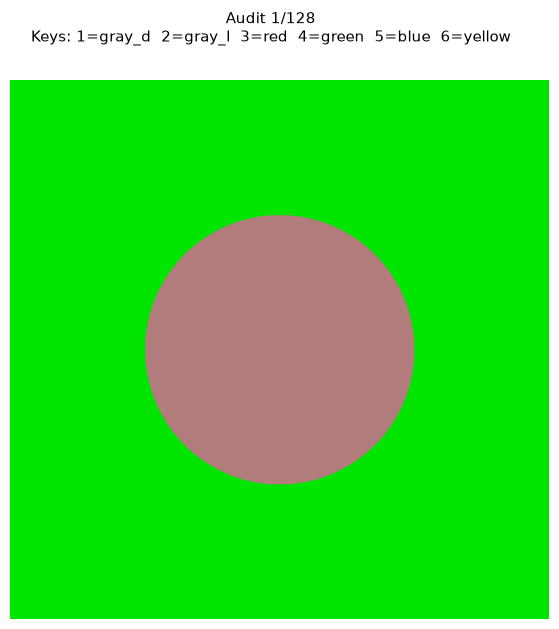

In [41]:
## 16. Audit 2: Helper functions and perform human audit

def show_audit_image():  # Draw the current audit stimulus without showing metadata to the user
    row = AUDIT_DF.iloc[AUDIT_INDEX]  # Read the current audit row
    stim_id = int(row["stim_ID"])  # Get the stimulus index for image lookup
    img = np.asarray(IMGS_AUDIT[stim_id])  # Load the saved RGB stimulus image
    AX_AUDIT.clear()  # Clear the previous image from the axes
    AX_AUDIT.imshow(img)  # Show the current stimulus image
    AX_AUDIT.set_axis_off()  # Hide axis ticks and borders
    title_text = f"Audit {AUDIT_INDEX + 1}/{len(AUDIT_DF)}"  # Show only progress and hide stimulus metadata
    key_text = "Keys: 1=gray_d  2=gray_l  3=red  4=green  5=blue  6=yellow"  # Show the label key map
    FIG_AUDIT.suptitle(title_text + "\n" + key_text, fontsize=11)  # Write the minimal title block
    FIG_AUDIT.canvas.draw_idle()  # Refresh the figure in the notebook

def on_audit_key(event):  # Handle one keypress and save the chosen label
    global AUDIT_INDEX  # Update the notebook-level audit position
    key = str(event.key)  # Normalize the pressed key as text
    if key not in KEY_TO_LABEL:  # Ignore keys that are not class labels
        return  # Exit without changing anything
    chosen_label = KEY_TO_LABEL[key]  # Convert the keypress to a class label
    AUDIT_DF.loc[AUDIT_INDEX, "user_label"] = chosen_label  # Save the human-assigned label
    AUDIT_DF.loc[AUDIT_INDEX, "match_true_label"] = bool(chosen_label == AUDIT_DF.loc[AUDIT_INDEX, "true_label"])  # Save whether the human label matches the code label
    AUDIT_DF.to_csv(AUDIT_SAVE_PATH, index=False)  # Save progress after every label
    AUDIT_INDEX += 1  # Advance to the next audit image
    if AUDIT_INDEX >= len(AUDIT_DF):  # Check whether the audit is finished
        AX_AUDIT.clear()  # Remove the last image from the axes
        AX_AUDIT.set_axis_off()  # Keep the finished view clean
        FIG_AUDIT.suptitle("Audit complete. Labels saved to:\n" + AUDIT_SAVE_PATH, fontsize=12)  # Show the completion message
        FIG_AUDIT.canvas.draw_idle()  # Refresh the finished figure
        return  # Stop after the last image is labeled
    show_audit_image()  # Draw the next audit image

FIG_AUDIT, AX_AUDIT = plt.subplots(figsize=(7, 7))  # Create one figure for the labeling session
CID_AUDIT = FIG_AUDIT.canvas.mpl_connect("key_press_event", on_audit_key)  # Connect keyboard input to the audit handler
show_audit_image()  # Draw the first randomized audit image
plt.show()  # Display the interactive audit figure


In [42]:
## 17. Audit 3: Save a print human labels

# ----------------------------                                              
# Audit comparison summary + export                                           # Summarize agreement between human labels and code labels
audit_base_path = os.path.splitext(AUDIT_SAVE_PATH)[0]                       # Remove the .csv suffix from the audit file path
AUDIT_SUMMARY_PATH = audit_base_path + "_summary.csv"                        # Build the summary-table export path
AUDIT_CROSSTAB_PATH = audit_base_path + "_crosstab.csv"                      # Build the confusion-style table export path
AUDIT_MISMATCH_PATH = audit_base_path + "_mismatches.csv"                    # Build the mismatch-table export path

# ----------------------------                                               
# Clean labels + recompute match flag                                         # Normalize the audit table before summarizing
user_label_text = AUDIT_DF["user_label"].fillna("").astype(str).str.strip()  # Normalize the human labels as clean text
labeled_mask = user_label_text.ne("")                                        # Mark rows that received a human label
AUDIT_DF["user_label"] = user_label_text                                     # Write the cleaned human labels back into the audit table
AUDIT_DF["match_true_label"] = pd.NA                                         # Reset the match column before recomputing it
AUDIT_DF.loc[labeled_mask, "match_true_label"] = (                           # Recompute matches only for labeled rows
    AUDIT_DF.loc[labeled_mask, "user_label"] == AUDIT_DF.loc[labeled_mask, "true_label"]  # 0Compare human labels to code labels
)                                                                           

# ----------------------------                                              
# Add RGB columns from metadata.csv                                           # Bring center and background RGB values into the audit table
meta_rgb_df = pd.read_csv(META_CSV_PATH)[                                    # Load only the metadata columns needed for RGB lookup
    ["stim_ID", "obj_r", "obj_g", "obj_b", "bg_r", "bg_g", "bg_b"]          # Keep stimulus ID plus object and background RGB columns
].copy()                                                                     

AUDIT_DF = AUDIT_DF.drop(                                                    # emove any old RGB columns so the merge stays clean
    columns=["obj_r", "obj_g", "obj_b", "bg_r", "bg_g", "bg_b"],            # RGB columns that may already exist from a prior run
    errors="ignore",                                                         # Ignore the drop if those columns are absent
)                                                                           

AUDIT_DF = AUDIT_DF.merge(                                                   # Merge the RGB values into the audit table by stimulus ID
    meta_rgb_df,                                                             # Metadata table containing RGB values
    on="stim_ID",                                                            # Match rows by stimulus ID
    how="left",                                                              # Keep all audit rows even if a lookup failed
)                                                                            

AUDIT_DF["obj_rgb"] = AUDIT_DF.apply(                                        # Build a formatted object RGB text column
    lambda row: f"[{row['obj_r']:.6f},{row['obj_g']:.6f},{row['obj_b']:.6f}]",  # Format object RGB as [r,g,b]
    axis=1,                                                                  # Apply the formatter row by row
)                                                                           
AUDIT_DF["bg_rgb"] = AUDIT_DF.apply(                                         # Build a formatted background RGB text column
    lambda row: f"[{row['bg_r']:.6f},{row['bg_g']:.6f},{row['bg_b']:.6f}]",  
    axis=1,                                                                  
)                                                                            

AUDIT_DF.to_csv(AUDIT_SAVE_PATH, index=False)                                # Re-save the audit table with cleaned labels, matches, and RGB values

# ----------------------------                                               
# Build labeled and mismatch tables                                           # Keep only rows needed for summary and error review
audit_labeled_df = AUDIT_DF.loc[labeled_mask].copy()                         # Keep only labeled rows for summary statistics
audit_mismatch_df = audit_labeled_df.loc[                                    # Keep only labeled rows where the human and code labels disagree
    ~audit_labeled_df["match_true_label"].astype(bool),                      # Invert the match flag to isolate mismatches
    [                                                                       
        "stim_ID",                                                          
        "true_label",                                                        # Code-generated label
        "user_label",                                                        # Human-assigned label
        "bg_hue",                                                            # Background hue label
        "obj_rgb",                                                           # Formatted object RGB text
        "bg_rgb",                                                            # Formatted background RGB text
        "obj_int",                                                           # Object intensity
        "obj_sat",                                                           # Object saturation
        "bg_int",                                                            # Background intensity
        "bg_sat",                                                            # Background saturation
    ],                                                                       
].copy()                                                                     

# ----------------------------                                               
# Compute summary statistics                                                  # Build overall counts for the audit stage
n_total = int(len(AUDIT_DF))                                                 # Count all audit rows
n_labeled = int(labeled_mask.sum())                                          # Count labeled audit rows
n_unlabeled = int(n_total - n_labeled)                                       # Count unlabeled audit rows
n_matches = int(audit_labeled_df["match_true_label"].sum()) if n_labeled > 0 else 0  # Count labeled rows that matched
n_mismatches = int(len(audit_mismatch_df))                                   # Count labeled rows that mismatched
agreement_rate = float(n_matches / n_labeled) if n_labeled > 0 else np.nan   # Compute human-versus-code agreement on labeled rows

audit_summary_df = pd.DataFrame([{                                           # Build a one-row overall summary table
    "n_total": n_total,                                                      # Total audit rows
    "n_labeled": n_labeled,                                                  # Total labeled rows
    "n_unlabeled": n_unlabeled,                                              # Total unlabeled rows
    "n_matches": n_matches,                                                  # Total matching rows
    "n_mismatches": n_mismatches,                                            # Total mismatching rows
    "agreement_rate": agreement_rate,                                        # Match fraction among labeled rows
}])                                                                         

# ----------------------------                                               
# Build crosstab                                                             # Cross-tabulate human labels versus code labels
if n_labeled > 0:                                                            # Build the confusion-style table only when labels exist
    audit_crosstab_df = pd.crosstab(                                         # Cross-tabulate human labels against code labels
        audit_labeled_df["user_label"],                                      # Rows are human-assigned labels
        audit_labeled_df["true_label"],                                      # Columns are code-generated labels
        dropna=False,                                                        # Keep all observed label combinations
    )                                                                       
else:                                                                        # Handle the case with no completed labels
    audit_crosstab_df = pd.DataFrame()                                       # Use an empty crosstab table

# ----------------------------                                                
# Export summary tables                                                      # Save the audit outputs to disk
audit_summary_df.to_csv(AUDIT_SUMMARY_PATH, index=False)                     # Export the overall summary table
audit_crosstab_df.to_csv(AUDIT_CROSSTAB_PATH)                                # Export the confusion-style table
audit_mismatch_df.to_csv(AUDIT_MISMATCH_PATH, index=False)                   # Export the mismatch table

# ----------------------------                                               
# Display outputs                                                            # Print paths and show the output tables
print("Audit table path:", AUDIT_SAVE_PATH)                                  # Confirm the updated audit table path
print("Audit summary path:", AUDIT_SUMMARY_PATH)                             # Confirm the summary-table path
print("Audit crosstab path:", AUDIT_CROSSTAB_PATH)                           # Confirm the crosstab-table path
print("Audit mismatch path:", AUDIT_MISMATCH_PATH)                           # Confirm the mismatch-table path

print("=== AUDIT SUMMARY ===")                                               
display(audit_summary_df)                                                    # Display the one-row overall summary table

print("=== HUMAN LABEL vs CODE LABEL ===")                                   
display(audit_crosstab_df)                                                   # Display the confusion-style comparison table

print("=== MISMATCHES ===")                                                 
display(audit_mismatch_df)                                                   # Display the mismatching audit rows with formatted RGB values


Audit table path: export_retina_20260825_102551/human_audit_labels_gray_plus_red_bg_gray_red_yellow_blue_green.csv
Audit summary path: export_retina_20260825_102551/human_audit_labels_gray_plus_red_bg_gray_red_yellow_blue_green_summary.csv
Audit crosstab path: export_retina_20260825_102551/human_audit_labels_gray_plus_red_bg_gray_red_yellow_blue_green_crosstab.csv
Audit mismatch path: export_retina_20260825_102551/human_audit_labels_gray_plus_red_bg_gray_red_yellow_blue_green_mismatches.csv
=== AUDIT SUMMARY ===


,n_total,n_labeled,n_unlabeled,n_matches,n_mismatches,agreement_rate
0,128,0,128,0,0,NaN


=== HUMAN LABEL vs CODE LABEL ===


""


=== MISMATCHES ===


,stim_ID,true_label,user_label,bg_hue,obj_rgb,bg_rgb,obj_int,obj_sat,bg_int,bg_sat


Gallery for true_label='red' at obj_int=0.700, obj_sat=0.700  (18 images)


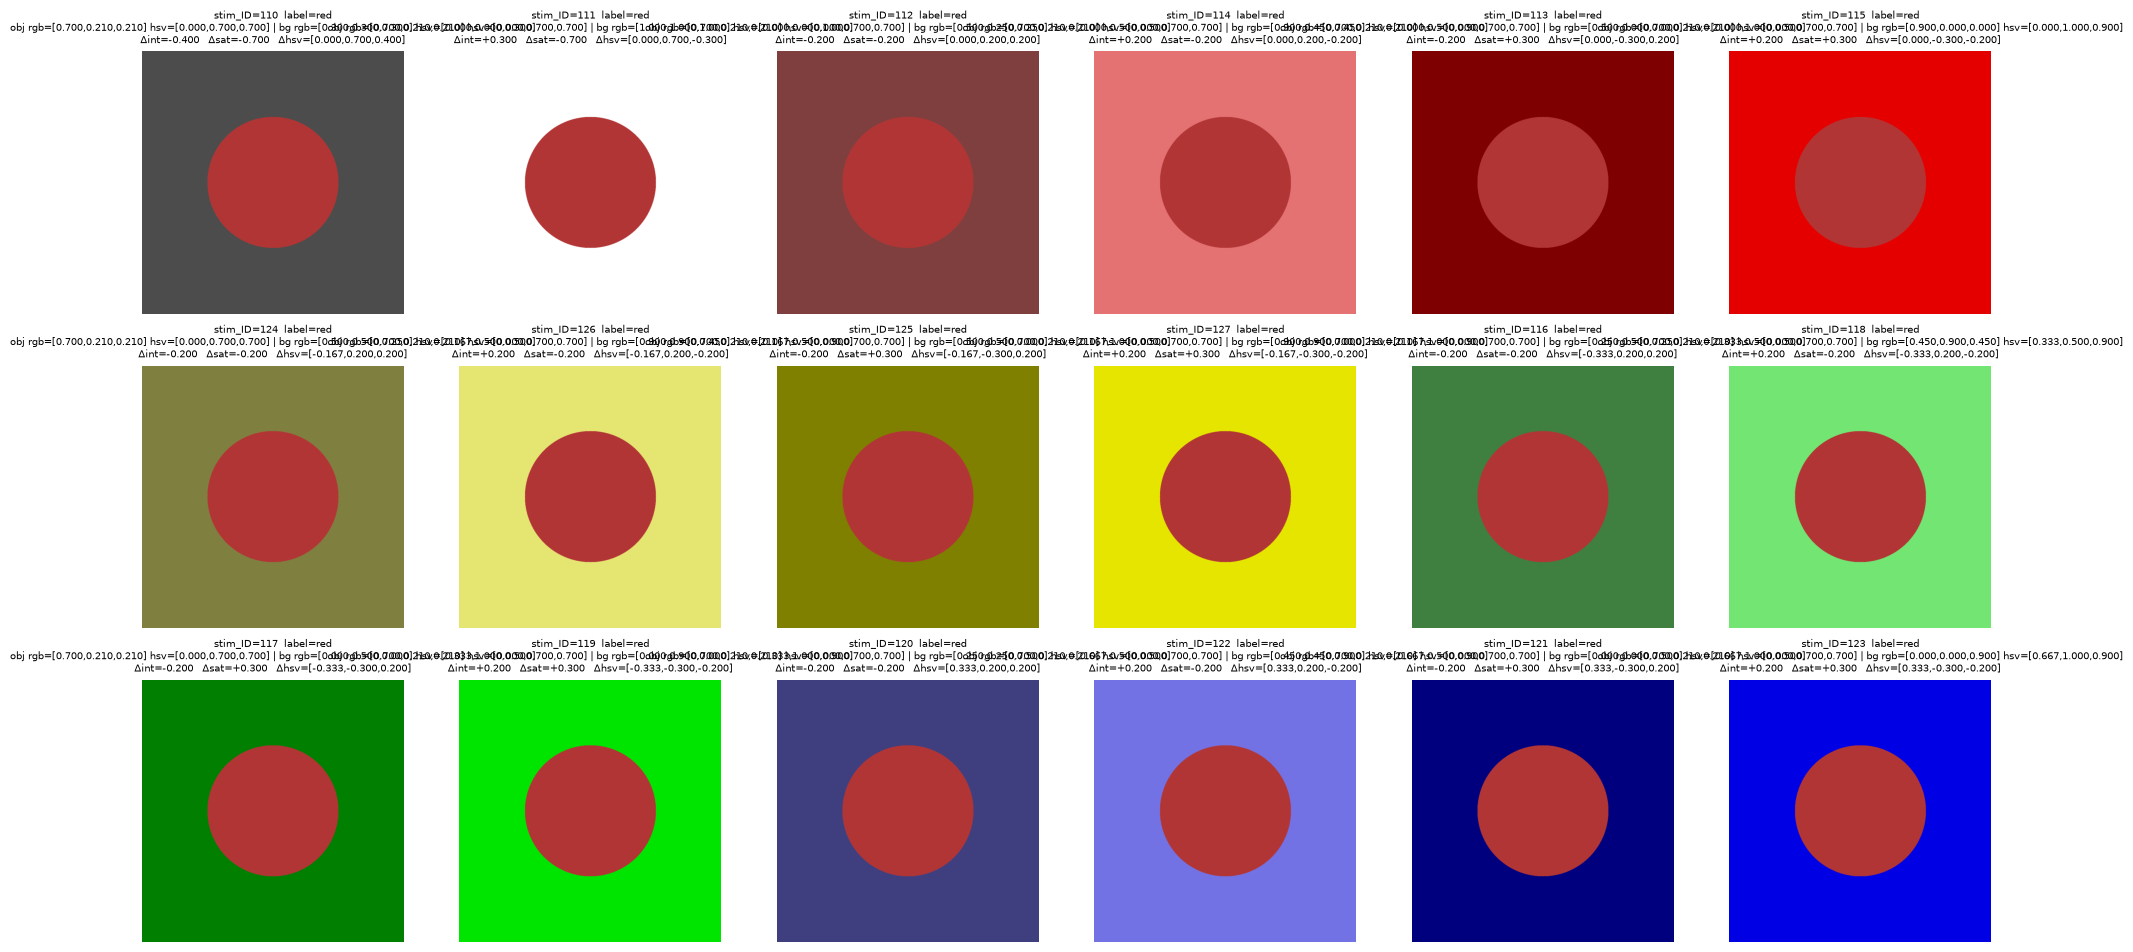

In [43]:
## 18. Gallery for one code label, true_label, at mid object settings  

%matplotlib inline  
# Ensure this viewer works without widgets

# =========================
# USER SETTINGS (edit here)
# =========================
TARGET_LABEL = "red"   # Choose: "gray_d","gray_l","red","green","blue","yellow"
N_COLS = 6             # Grid columns for the gallery figure

SAVE_PNG = False       # Set True to save a PNG
DPI = 200              # Save resolution

# -------------------------
# Load dataset + metadata
root = zarr.open_group(ZARR_PATH, mode="r")  # Open the Zarr dataset 
imgs_z = root["imgs"]                        # RGB stimuli: (N, H, W, 3)

meta = pd.read_csv(META_CSV_PATH)            # Load the single metadata CSV
meta_label = meta[meta["true_label"] == TARGET_LABEL].copy()  # Keep only rows for this label

if len(meta_label) == 0:  # Clear error if label doesn't exist in the dataset
    raise ValueError(f"No stimuli found with true_label='{TARGET_LABEL}'.")  # Stop early

# -------------------------
# Choose the "mid" object setting for this label (mid intensity, and mid saturation if chromatic)

if TARGET_LABEL in ("gray_d", "gray_l"):  # Gray labels: choose mid intensity within the dark or light half
    if TARGET_LABEL == "gray_d":  # Dark half
        target_obj_int = 0.5 * (S["OBJ_GRAY_MIN"] + GRAY_LIGHT_THRESHOLD)  # Midpoint of dark range
    else:  # Light half
        target_obj_int = 0.5 * (GRAY_LIGHT_THRESHOLD + S["OBJ_GRAY_MAX"])  # Midpoint of light range
    target_obj_sat = 0.0  # Gray saturation is always 0
else:  # Chromatic labels: mid intensity + mid saturation of the chromatic grids
    target_obj_int = 0.5 * (S["OBJ_CHROM_INT_MIN"] + S["OBJ_CHROM_INT_MAX"])  # Midpoint of chrom intensity range
    target_obj_sat = 0.5 * (S["OBJ_CHROM_SAT_MIN"] + S["OBJ_CHROM_SAT_MAX"])  # Midpoint of chrom saturation range

# Find the closest available (obj_int, obj_sat) that actually exists in the dataset for this label
obj_settings = meta_label[["obj_int", "obj_sat"]].drop_duplicates()  # Unique object settings for this label
obj_settings = obj_settings.assign(  # Score by closeness to "mid"
    score=(obj_settings["obj_int"] - target_obj_int).abs() + (obj_settings["obj_sat"] - target_obj_sat).abs()
)
best = obj_settings.sort_values("score", ascending=True).iloc[0]  # Choose closest setting
best_obj_int = float(best["obj_int"])  # Selected object intensity
best_obj_sat = float(best["obj_sat"])  # Selected object saturation

# Filter to all stimuli that share this exact object setting (i.e., object on all backgrounds)
tol = 1e-9  # Tight tolerance for float matching (values come from linspace)
sel = meta_label[
    np.isclose(meta_label["obj_int"], best_obj_int, atol=tol) &
    np.isclose(meta_label["obj_sat"], best_obj_sat, atol=tol)
].copy()  # All backgrounds for this object setting

if len(sel) == 0:  # Guard (should not happen)
    raise RuntimeError("Selection failed: could not find rows for the chosen (obj_int,obj_sat).")  # Stop

# Sort backgrounds in a human-friendly way using HSV of bg color
def _is_gray_rgb(r, g, b, tol=1e-6):  # Simple helper: identify grayscale backgrounds
    return (abs(r - g) < tol) and (abs(g - b) < tol)  # Gray if channels match

bg_hsv = np.vstack([  # Compute HSV for sorting backgrounds
    rgb_to_hsv01([r, g, b]) for r, g, b in sel[["bg_r", "bg_g", "bg_b"]].to_numpy()
])
sel["bg_h"] = bg_hsv[:, 0]  # Hue
sel["bg_s"] = bg_hsv[:, 1]  # Sat
sel["bg_v"] = bg_hsv[:, 2]  # Value
sel["bg_is_gray"] = [  # Gray-first ordering
    _is_gray_rgb(r, g, b) for r, g, b in sel[["bg_r", "bg_g", "bg_b"]].to_numpy()
]
sel = sel.sort_values(["bg_is_gray", "bg_h", "bg_s", "bg_v"], ascending=[False, True, True, True])  # Sort backgrounds

print(  # Quick audit
    f"Gallery for true_label='{TARGET_LABEL}' at obj_int={best_obj_int:.3f}, obj_sat={best_obj_sat:.3f}  "
    f"({len(sel)} images)"
)

# -------------------------
# Plot gallery
n_imgs = len(sel)  # Number of images in this gallery
ncols = int(N_COLS)  # Columns
nrows = int(np.ceil(n_imgs / ncols))  # Rows

fig, axs = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), squeeze=False)  

def _fmt3(v):  # Compact [x,y,z] formatter for titles
    v = np.asarray(v, dtype=float)  
    return f"[{v[0]:.3f},{v[1]:.3f},{v[2]:.3f}]"  

for idx, row in enumerate(sel.itertuples(index=False)):  # One tile per stimulus
    r = idx // ncols  # Row index
    c = idx % ncols   # Col index
    ax = axs[r, c]    # Axis for this tile

    stim_id = int(row.stim_ID)  # Zarr index = stim_ID
    img = imgs_z[stim_id]       # Load one RGB image from Zarr

    obj_rgb = np.array([row.obj_r, row.obj_g, row.obj_b], dtype=float)  # Object RGB
    bg_rgb = np.array([row.bg_r, row.bg_g, row.bg_b], dtype=float)      # Background RGB
    hsv_obj = rgb_to_hsv01(obj_rgb)  # Object HSV
    hsv_bg = rgb_to_hsv01(bg_rgb)    # Background HSV
    dhsv = hsv_delta(hsv_obj, hsv_bg)  # HSV delta 

    ax.imshow(img, origin="lower")  # Show stimulus
    ax.axis("off")                 

    line1 = f"stim_ID={stim_id}  label={TARGET_LABEL}"  
    line2 = f"obj rgb={_fmt3(obj_rgb)} hsv={_fmt3(hsv_obj)} | bg rgb={_fmt3(bg_rgb)} hsv={_fmt3(hsv_bg)}"  
    line3 = f"Δint={float(row.delta_int):+.3f}   Δsat={float(row.delta_sat):+.3f}   Δhsv={_fmt3(dhsv)}"  # 02.22.2026 Title line 

    ax.set_title(line1 + "\n" + line2 + "\n" + line3, fontsize=7)  

# Turn off any unused axes (if grid not full)
for idx in range(n_imgs, nrows * ncols):  # Hide empty tiles
    axs[idx // ncols, idx % ncols].axis("off")  

fig.tight_layout()  

# -------------------------
# Optional save
if SAVE_PNG:  # Save the gallery as a PNG if requested
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")  # Timestamp
    safe_label = "".join(ch if ch.isalnum() else "_" for ch in TARGET_LABEL)  # 0Filename-safe label
    png_name = f"gallery_{safe_label}_{ts}.png"  # Filename includes label + timestamp
    png_path = os.path.join(RUN_DIR, png_name)   # Save alongside dataset outputs
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")  # Write PNG
    print("Saved:", png_path)  

plt.show()  # Display figure inline

In [44]:
# 19. Curvature extrema masks (Zarr-based)  # read raw outs from Zarr, write masks back to Zarr

# =========================
# USER SETTINGS 
# =========================
sigma_px = 0.5          # Gaussian smoothing (pixels)
amp_thresh = 0.0        # Ignore tiny extrema by amplitude (0 keeps everything)
grad_tol_frac = 0.7     # How close directional derivative must be to 0 (smaller=stricter)
curv_tol_frac = 0.20    # Required curvature strength (bigger=stricter)

SAVE_SMOOTH = False     # Don't double storage unless you need it
SAVE_WEIGHTED = False   # Compute later as (raw * mask) if needed

# -------------------------
# Mask function 
def ridge_valley_mask(A, amp_thresh=0.0, grad_tol_frac=0.02, curv_tol_frac=0.10):  
    A = np.asarray(A, dtype=float)                                   

    gy, gx = np.gradient(A)                                          # First derivatives
    gxx = np.gradient(gx, axis=1)                                    # Second derivatives
    gyy = np.gradient(gy, axis=0)
    gxy = np.gradient(gx, axis=0)

    tr = gxx + gyy                                                   # Hessian trace
    det = gxx * gyy - gxy * gxy                                      # Hessian determinant
    tmp = np.sqrt(np.maximum(0.0, (0.5 * tr) ** 2 - det))            # Eigenvalue helper

    lam1 = 0.5 * tr - tmp                                            # Smaller eigenvalue (more negative curvature)
    lam2 = 0.5 * tr + tmp                                            # Larger eigenvalue (more positive curvature)

    vx1 = gxy                                                        # Eigenvector (one valid form)
    vy1 = lam1 - gxx
    nrm = np.hypot(vx1, vy1) + 1e-12                                 # Safe normalization
    vx1 /= nrm
    vy1 /= nrm

    d1 = gx * vx1 + gy * vy1                                         # Directional derivative along v1

    grad_ref = np.percentile(np.abs(d1), 99)                         # Robust gradient scale
    curv_ref = np.percentile(np.abs(lam1), 99)                       # Robust curvature scale
    grad_tol = grad_tol_frac * grad_ref                              # Derivative ~ 0 tolerance
    curv_tol = curv_tol_frac * curv_ref                              # Curvature magnitude threshold

    ridge_max = (np.abs(d1) < grad_tol) & (lam1 < -curv_tol) & (np.abs(A) > amp_thresh)  # Bright ridge mask

    vx2 = -vy1                                                       # Orthogonal direction
    vy2 =  vx1
    d2 = gx * vx2 + gy * vy2                                         # Directional derivative along v2

    valley_min = (np.abs(d2) < grad_tol) & (lam2 > curv_tol) & (np.abs(A) > amp_thresh)  # Dark valley mask

    return ridge_max | valley_min                                    # Combined extrema-like mask

# -------------------------
# Zarr IO 
if "ZARR_PATH" not in globals():                                     
    raise RuntimeError("ZARR_PATH not found. Generate stimuli first.")    # Stop early with guidance

root = zarr.open_group(ZARR_PATH, mode="a")                           # Open existing dataset for appending derived arrays
outs_z = root["outs"]                                                 # Raw response maps: (N, K, H, W)

N, K, H, W = outs_z.shape                                             # Dataset dimensions
print("Using outs shape:", outs_z.shape)                              

# Create / overwrite derived arrays
derived = root.require_group("derived")                               # Store derived products in a subgroup

# Use the same style of codec as stimuli generator (Zarr v3)
compressors = zarr.codecs.BloscCodec(                                 # Zarr v3 codec
    cname="zstd",
    clevel=3,
    shuffle=zarr.codecs.BloscShuffle.bitshuffle,
)

chunk_hw = int(min(256, H, W))                                        # Reasonable chunk size

for name in ["outs_extrema_mask", "outs_smooth", "outs_extrema_weighted"]:  # Overwrite behavior 
    if name in derived:                                               # If rerunning cell, replace outputs
        del derived[name]                                             # Delete old derived array

mask_z = derived.create_array(                                        # Store masks as uint8 (0/1)
    name="outs_extrema_mask",
    shape=(N, K, H, W),
    chunks=(1, 1, chunk_hw, chunk_hw),
    dtype="u1",
    compressors=compressors,
)

smooth_z = None                                                       # Optional storage
weighted_z = None                                                     # Optional storage

if SAVE_SMOOTH:                                                       # Only create if requested
    smooth_z = derived.create_array(
        name="outs_smooth",
        shape=(N, K, H, W),
        chunks=(1, 1, chunk_hw, chunk_hw),
        dtype="f4",
        compressors=compressors,
    )

if SAVE_WEIGHTED:                                                     # Only create if requested
    weighted_z = derived.create_array(
        name="outs_extrema_weighted",
        shape=(N, K, H, W),
        chunks=(1, 1, chunk_hw, chunk_hw),
        dtype="f4",
        compressors=compressors,
    )

# Record parameters used for reproducibility
derived.attrs.update({                                                # Save mask parameters alongside derived outputs
    "sigma_px": float(sigma_px),
    "amp_thresh": float(amp_thresh),
    "grad_tol_frac": float(grad_tol_frac),
    "curv_tol_frac": float(curv_tol_frac),
    "SAVE_SMOOTH": bool(SAVE_SMOOTH),
    "SAVE_WEIGHTED": bool(SAVE_WEIGHTED),
})

# -------------------------
# Compute masks
pbar14 = tqdm(total=N * K, desc="Cell 14: extrema masks")              # Progress over stim × channel

for stim_id in range(N):                                              # Loop stimuli
    for ch in range(K):                                               # Loop channels
        A = outs_z[stim_id, ch]                                        # Load one (H,W) map from Zarr
        As = gaussian_filter(A, sigma=sigma_px, mode="reflect")        # Smooth map
        m = ridge_valley_mask(As, amp_thresh=amp_thresh,
                              grad_tol_frac=grad_tol_frac,
                              curv_tol_frac=curv_tol_frac)            # Compute extrema mask

        mask_z[stim_id, ch] = m.astype(np.uint8)                      # Save mask (0/1)

        if smooth_z is not None:                                      # Optional save
            smooth_z[stim_id, ch] = As.astype(np.float32)             # Save smoothed responses

        if weighted_z is not None:                                    # Optional save
            weighted_z[stim_id, ch] = (A * m).astype(np.float32)       # Save raw values only at mask pixels

        pbar14.update(1)                                              

pbar14.close()                                                        
print("Done. Masks saved to:", f"{ZARR_PATH}/derived/outs_extrema_mask")  # Confirm output location

Using outs shape: (392, 9, 1000, 1000)


/var/folders/vg/n2m2_qzs4m7bxgtf53y__2w00000gn/T/ipykernel_30187/1751479659.py:72: DeprecationWarning: BloscShuffle.bitshuffle is deprecated; pass the string 'bitshuffle' instead.
  shuffle=zarr.codecs.BloscShuffle.bitshuffle,


Cell 14: extrema masks:   0%|          | 0/3528 [00:00<?, ?it/s]

Done. Masks saved to: export_retina_20260825_102551/dataset.zarr/derived/outs_extrema_mask


In [45]:
# 20. Nearest-seed "fill-in" for ALL stimuli (Zarr-based)  # Use Zarr outs + extrema masks 

# =========================
# USER SETTINGS (edit here)
# =========================
fillradius = None                 # None = fill everywhere; or set an int radius in pixels (e.g., 300)
beyondradius = False              # If fillradius set: True keeps original outs beyond radius; False sets beyond-radius pixels to 0

SAVE_OUTS_FILL = True             # Save filled response maps to Zarr (this is the main output)
SAVE_OUTS_DIST = False            # Save distance-to-nearest-seed maps (very large; off by default)
SAVE_OUTS_FILL_MASK = False       # Save the fill update mask (very large; off by default)

OUTS_FILL_DTYPE = "f4"            # Output dtype for outs_fill ("f4" float32 recommended)
OUTS_DIST_DTYPE = "f4"            # Output dtype for outs_dist if saved
CHUNK_HW = 256                    # Chunk size for spatial dims in Zarr (tradeoff: speed vs file fragmentation)

# -------------------------
# Safety checks + open Zarr
if "ZARR_PATH" not in globals():                                              # Make dependency explicit
    raise RuntimeError("ZARR_PATH not found. Generate stimuli first.")             # top early with clear instruction

root = zarr.open_group(ZARR_PATH, mode="a")                                    # Open dataset for appending derived products
outs_z = root["outs"]                                                          # Raw response maps: (N, K, H, W)

if "derived" not in root:                                                      # Ensure derived group exists
    raise RuntimeError("Missing 'derived' group. Run extrema masks first.")  # Stop early

derived = root["derived"]                                                      # Derived products group
if "outs_extrema_mask" not in derived:                                         # Ensure extrema masks exist
    raise RuntimeError("Missing derived/outs_extrema_mask. Run extrema masks first.")# Stop early

mask_z = derived["outs_extrema_mask"]                                          # Extrema masks: (N, K, H, W), uint8

N, K, H, W = outs_z.shape                                                      # Dimensions
print("Using shapes:", {"outs": outs_z.shape, "mask": mask_z.shape})           # Quick audit

# -------------------------
# Estimate storage (helps users avoid surprises)
def _gib(nbytes):                                                               # Tiny helper for readable size estimates
    return float(nbytes) / (1024.0 ** 3)                                        # Convert bytes → GiB

bytes_fill = int(N * K * H * W * np.dtype(OUTS_FILL_DTYPE).itemsize)            # Uncompressed size estimate for outs_fill
bytes_dist = int(N * K * H * W * np.dtype(OUTS_DIST_DTYPE).itemsize)            # Uncompressed size estimate for outs_dist
bytes_fmsk = int(N * K * H * W * np.dtype("u1").itemsize)                       # Uncompressed size estimate for outs_fill_mask (uint8)

print("Estimated UNCOMPRESSED sizes (GiB):", {                                  # Informative print
    "outs_fill": _gib(bytes_fill) if SAVE_OUTS_FILL else 0.0,                   
    "outs_dist": _gib(bytes_dist) if SAVE_OUTS_DIST else 0.0,                   
    "outs_fill_mask": _gib(bytes_fmsk) if SAVE_OUTS_FILL_MASK else 0.0,         
})                                                                             

# -------------------------
# Create / replace output arrays in Zarr (simple overwrite behavior)
compressors = zarr.codecs.BloscCodec(                                           # Zarr v3 codec 
    cname="zstd",                                                               # zstd compression
    clevel=3,                                                                   # moderate compression level
    shuffle=zarr.codecs.BloscShuffle.bitshuffle,                                # bitshuffle for numeric data
)                                                                              

chunk_hw = int(min(CHUNK_HW, H, W))                                             # Clip chunk to image size

for name in ["outs_fill", "outs_dist", "outs_fill_mask"]:                       # Remove old outputs if rerunning
    if name in derived:                                                         
        del derived[name]                                                       

fill_z = None                                                                   
dist_z = None                                                                  
fmsk_z = None                                                                  

if SAVE_OUTS_FILL:                                                              # Create outs_fill if requested
    fill_z = derived.create_array(                                            
        name="outs_fill",                                                       
        shape=(N, K, H, W),                                                   
        chunks=(1, 1, chunk_hw, chunk_hw),                                      
        dtype=OUTS_FILL_DTYPE,                                                 
        compressors=compressors,                                               
    )                                                                          

if SAVE_OUTS_DIST:                                                              # Create outs_dist if requested
    dist_z = derived.create_array(                                             
        name="outs_dist",                                                     
        shape=(N, K, H, W),                                                    
        chunks=(1, 1, chunk_hw, chunk_hw),                                      
        dtype=OUTS_DIST_DTYPE,                                                  
        compressors=compressors,                                           
    )                                                                          

if SAVE_OUTS_FILL_MASK:                                                         # Create outs_fill_mask if requested
    fmsk_z = derived.create_array(                                             
        name="outs_fill_mask",                                                  
        shape=(N, K, H, W),                                                     
        chunks=(1, 1, chunk_hw, chunk_hw),                                    
        dtype="u1",                                                           
        compressors=compressors,                                              
    )                                                                           

derived.attrs.update({                                                          # Store parameters used for reproducibility
    "fillradius": None if fillradius is None else float(fillradius),            # Save radius choice
    "beyondradius": bool(beyondradius),                                         # Save beyond-radius behavior
    "SAVE_OUTS_FILL": bool(SAVE_OUTS_FILL),                                     # Save output toggles
    "SAVE_OUTS_DIST": bool(SAVE_OUTS_DIST),
    "SAVE_OUTS_FILL_MASK": bool(SAVE_OUTS_FILL_MASK),
    "OUTS_FILL_DTYPE": str(OUTS_FILL_DTYPE),                                    # Save dtypes
    "OUTS_DIST_DTYPE": str(OUTS_DIST_DTYPE),
})                                                                              

# -------------------------
# Main fill loop (stimulus × channel)
pbar15 = tqdm(total=N * K, desc="Cell 15: nearest-seed fill")                   # Progress over stim × channel

for stim_id in range(N):                                                       # Loop stimuli
    for ch in range(K):                                                        # Loop response channels
        A = np.asarray(outs_z[stim_id, ch], dtype=float)                       # Load raw response (H,W)
        seed_mask = np.asarray(mask_z[stim_id, ch], dtype=bool)                # Seeds are extrema pixels (True where seeds exist)

        if not np.any(seed_mask):                                              # If no seeds, cannot propagate
            if fill_z is not None:                                             # Save if requested
                fill_z[stim_id, ch] = np.zeros_like(A, dtype=np.float32)       # Convention: fill output is all zeros
            if dist_z is not None:                                             # Save if requested
                dist_z[stim_id, ch] = np.full_like(A, np.nan, dtype=np.float32)# Distances undefined -> NaN
            if fmsk_z is not None:                                             # Save if requested
                fmsk_z[stim_id, ch] = np.zeros_like(seed_mask, dtype=np.uint8) # Nothing updated
            pbar15.update(1)                                                  
            continue                                                          

        dist_map, inds = distance_transform_edt(~seed_mask, return_indices=True)  # Distance + nearest-seed indices
        nearest_vals = A[inds[0], inds[1]]                                     # Value at nearest seed for each pixel (from raw A)

        fill_mask = ~seed_mask                                                 # Never overwrite seed pixels
        if fillradius is not None:                                             # Optional radius restriction
            fill_mask = fill_mask & (dist_map <= float(fillradius))            # Only fill within radius

        filled = A.copy()                                                      # Start from raw output (enables "keep original" behavior)
        filled[fill_mask] = nearest_vals[fill_mask]                            # Fill selected pixels with nearest seed value

        if (fillradius is not None) and (not beyondradius):                    # If user wants zeros beyond radius
            beyond = (~seed_mask) & (dist_map > float(fillradius))             # Pixels beyond radius and not seeds
            filled[beyond] = 0.0                                               # Set beyond-radius pixels to zero

        if fill_z is not None:                                                 # Save outs_fill if requested
            fill_z[stim_id, ch] = filled.astype(np.float32)                    # Store filled map (float32)

        if dist_z is not None:                                                 # Save outs_dist if requested
            dist_z[stim_id, ch] = dist_map.astype(np.float32)                  # Store distance map (float32)

        if fmsk_z is not None:                                                 # Save outs_fill_mask if requested
            fmsk_z[stim_id, ch] = fill_mask.astype(np.uint8)                   # Store update mask (0/1)

        del A, seed_mask, dist_map, inds, nearest_vals, fill_mask, filled      # Free large temporaries
        pbar15.update(1)                                                       

pbar15.close()                                                                
print("Done. Saved to Zarr under:", f"{ZARR_PATH}/derived/")                   # Confirm output location

Using shapes: {'outs': (392, 9, 1000, 1000), 'mask': (392, 9, 1000, 1000)}
Estimated UNCOMPRESSED sizes (GiB): {'outs_fill': 13.142824172973633, 'outs_dist': 0.0, 'outs_fill_mask': 0.0}


/var/folders/vg/n2m2_qzs4m7bxgtf53y__2w00000gn/T/ipykernel_30187/4260858581.py:57: DeprecationWarning: BloscShuffle.bitshuffle is deprecated; pass the string 'bitshuffle' instead.
  shuffle=zarr.codecs.BloscShuffle.bitshuffle,                                # bitshuffle for numeric data


Cell 15: nearest-seed fill:   0%|          | 0/3528 [00:00<?, ?it/s]

Done. Saved to Zarr under: export_retina_20260825_102551/dataset.zarr/derived/


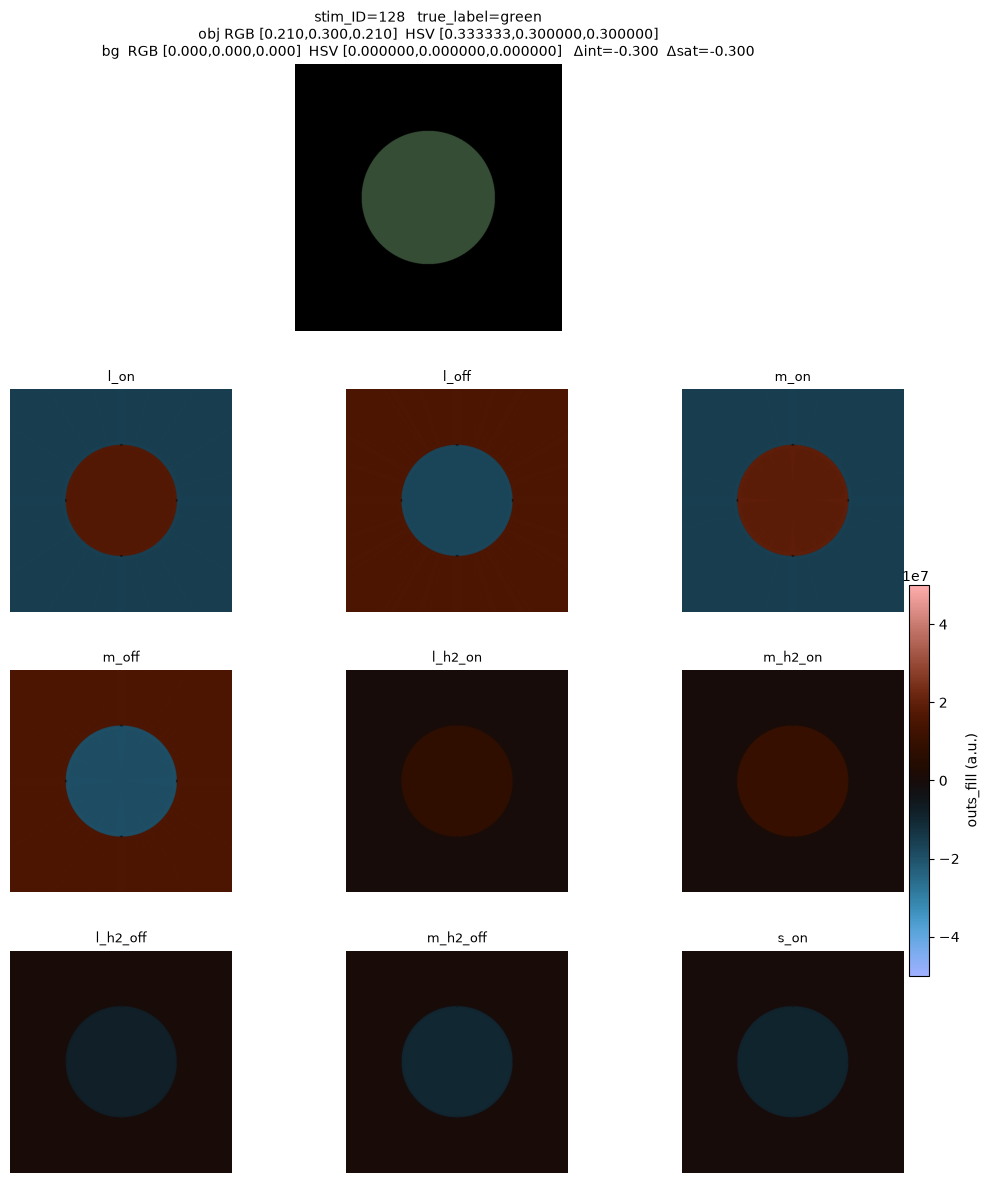

Index 1/8  (stim_ID=128)


In [46]:
# 21. Simple Zarr viewer: stimulus (top) + outs_fill for ALL RGC models (below)  

# =========================
# USER SETTINGS (edit here)
# =========================
OBJ_LABEL = "green"            # code label, true_label, to view (e.g., "gray_l","gray_d","red","green","blue","yellow")
BG_LABEL  = "gray"           # background hue to view (must exist in metadata.csv as column "bg_hue")

RESP_CMAP = "berlin"        # "viridis" is alternative, simple, always-available colormap
USE_FIXED_SCALE = True       # keep one scale as you cycle stimuli
VMIN, VMAX = -5e7, 5e7       # fixed color scale for outs_fill 

N_COLS = 3                   # columns for the response grid below the stimulus
OUTDIR_VIEWER = "outputs_16_viewer_pngs"  # where saved PNGs go (if you use save_current_png)

# -------------------------
# Safety checks 
if "ZARR_PATH" not in globals():                                # require stimuli generation
    raise RuntimeError("ZARR_PATH not found. Generate stimuli first.")  # stop early

if "META_CSV_PATH" not in globals():                            # require stimuli generation
    raise RuntimeError("META_CSV_PATH not found. Generate stimuli first.")  # stop early

# -------------------------
# Load metadata + select matching stimuli
meta_df = pd.read_csv(META_CSV_PATH)                            # load metadata table

need_cols = {"stim_ID", "true_label", "bg_hue"}                 # required columns for filtering
missing = sorted(list(need_cols - set(meta_df.columns)))        # check required columns
if missing:                                                     
    raise RuntimeError(f"metadata.csv missing columns: {missing}. Make sure stimuli generator writes 'bg_hue'.")

sel = meta_df[(meta_df["true_label"] == OBJ_LABEL) & (meta_df["bg_hue"] == BG_LABEL)].copy()  # filter
sel = sel.sort_values("stim_ID")                                # stable order
stim_ids = sel["stim_ID"].astype(int).tolist()                  # list of stim_IDs to cycle

if len(stim_ids) == 0:                                          
    raise RuntimeError(f"No stimuli found for OBJ_LABEL={OBJ_LABEL}, BG_LABEL={BG_LABEL}.")

print(f"Viewer selection: {len(stim_ids)} stimuli for OBJ_LABEL={OBJ_LABEL}, BG_LABEL={BG_LABEL}")  

# -------------------------
# Open Zarr arrays (read-only)
root = zarr.open_group(ZARR_PATH, mode="r")                     # open dataset
imgs_z = root["imgs"]                                           # (N,H,W,3)

if "derived" not in root:                                       # require mask outputs
    raise RuntimeError("Missing group 'derived'. Run masking first.")

derived = root["derived"]                                       # derived products
if "outs_fill" not in derived:                                  # require mask output
    raise RuntimeError("Missing derived/outs_fill. Run masking first.")

fill_z = derived["outs_fill"]                                   # (N,K,H,W)

# Response (model) names for display
response_keys = list(root.attrs["RESPONSE_KEYS"])               
K = int(fill_z.shape[1])                                        # number of response maps

if len(response_keys) != K:                                     
    raise RuntimeError("Mismatch: len(RESPONSE_KEYS) != outs_fill.shape[1].")

# -------------------------
# Helper: render one stimulus as a figure (returns fig)
def _render_stim_figure(stim_id: int):                          # make a complete figure for one stim_ID
    stim_id = int(stim_id)                                      

    # Pull the metadata row for titles
    row = meta_df.loc[meta_df["stim_ID"] == stim_id].iloc[0]    # one row per stim_ID

    # Load stimulus + filled responses
    img = np.asarray(imgs_z[stim_id], dtype=float)              # (H,W,3)
    fills = np.asarray(fill_z[stim_id], dtype=float)            # (K,H,W)

    # Decide color scale
    if USE_FIXED_SCALE:                                         # fixed scale across cycling
        vmin, vmax = float(VMIN), float(VMAX)                   # user-chosen bounds
    else:                                                       # auto scale per stimulus 
        m = float(np.max(np.abs(fills)))                        # max magnitude across all models
        vmin, vmax = -m, m                                      # symmetric

    # Grid sizes
    ncols = int(N_COLS)                                         # response grid columns
    nrows = int(np.ceil(K / float(ncols)))                      # response grid rows

    # Figure layout: 1 row for stimulus + nrows for responses
    fig = plt.figure(figsize=(4.2 * ncols, 3.6 * (nrows + 1)))   
    gs = fig.add_gridspec(nrows + 1, ncols, height_ratios=[1.2] + [1.0] * nrows)  

    # Top: stimulus spans all columns
    ax0 = fig.add_subplot(gs[0, :])                             
    ax0.imshow(img, origin="lower")                             # show RGB stimulus
    ax0.axis("off")                                            

    # 3-line heading 
    line1 = f"stim_ID={stim_id}   true_label={row.get('true_label','')}"  
    line2 = f"obj RGB [{row.get('obj_r',np.nan):.3f},{row.get('obj_g',np.nan):.3f},{row.get('obj_b',np.nan):.3f}]  HSV {row.get('hsv_obj','')}"  
    line3 = f"bg  RGB [{row.get('bg_r',np.nan):.3f},{row.get('bg_g',np.nan):.3f},{row.get('bg_b',np.nan):.3f}]  HSV {row.get('hsv_bg','')}   Δint={row.get('delta_int',np.nan):.3f}  Δsat={row.get('delta_sat',np.nan):.3f}"  
    ax0.set_title(line1 + "\n" + line2 + "\n" + line3, fontsize=10)       

    # Bottom: outs_fill for each model (shared color scale + one colorbar)
    resp_axes = []                                              # collect axes for shared colorbar
    last_im = None                                              # keep handle for colorbar

    for i in range(K):                                          # one panel per response key
        r = i // ncols                                          # row index in grid
        c = i % ncols                                           # col index in grid
        ax = fig.add_subplot(gs[1 + r, c])                      # response axis

        last_im = ax.imshow(fills[i], origin="lower", cmap=RESP_CMAP, vmin=vmin, vmax=vmax)  # response map
        ax.set_title(str(response_keys[i]), fontsize=9)         # model name
        ax.axis("off")                                          

        resp_axes.append(ax)                                    # track axes for colorbar

    # Turn off any unused axes (if K not a multiple of ncols)
    for j in range(K, nrows * ncols):                            # remaining empty slots
        r = j // ncols                                          
        c = j % ncols                                            
        ax = fig.add_subplot(gs[1 + r, c])                       # empty axis
        ax.axis("off")                                           # hide it

    # One shared colorbar on the right
    if last_im is not None:                                      
        fig.colorbar(last_im, ax=resp_axes, fraction=0.02, pad=0.02, label="outs_fill (a.u.)")  

    fig.subplots_adjust(right=0.88, hspace=0.25)                
    return fig

# -------------------------
# Simple “cycling” state + functions (call next_stim() / prev_stim() in new notebook lines)
state16 = {"i": 0}                                               # current index into stim_ids

def show_current():                                              # display current stimulus
    clear_output(wait=True)                                      # refresh inline output cleanly
    stim_id = stim_ids[state16["i"]]                             # current stim_ID
    fig = _render_stim_figure(stim_id)                           # make figure
    plt.show()                                                   # show inline
    plt.close(fig)                                               
    print(f"Index {state16['i']+1}/{len(stim_ids)}  (stim_ID={stim_id})")  

def next_stim():                                                 # go forward
    state16["i"] = (state16["i"] + 1) % len(stim_ids)            
    show_current()                                              

def prev_stim():                                                 # go backward
    state16["i"] = (state16["i"] - 1) % len(stim_ids)            
    show_current()                                              

def goto_index(i: int):                                          # jump to a specific index (0-based)
    state16["i"] = int(i) % len(stim_ids)                        
    show_current()                                              

def save_current_png(dpi: int = 200):                            # save the current figure as PNG
    os.makedirs(OUTDIR_VIEWER, exist_ok=True)                    # ensure output folder exists
    stim_id = stim_ids[state16["i"]]                             # current stim_ID
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")                # timestamp for filename
    fname = f"viewer16_{ts}_stim{stim_id:06d}_obj{OBJ_LABEL}_bg{BG_LABEL}.png"  # filename
    fpath = os.path.join(OUTDIR_VIEWER, fname)                   # full path

    fig = _render_stim_figure(stim_id)                           # render fresh figure
    fig.savefig(fpath, dpi=dpi, bbox_inches="tight")             # save image
    plt.close(fig)                                               # close figure
    print("Saved:", fpath)                                      

# -------------------------
# Show the first stimulus immediately
show_current()                                                   # initial view

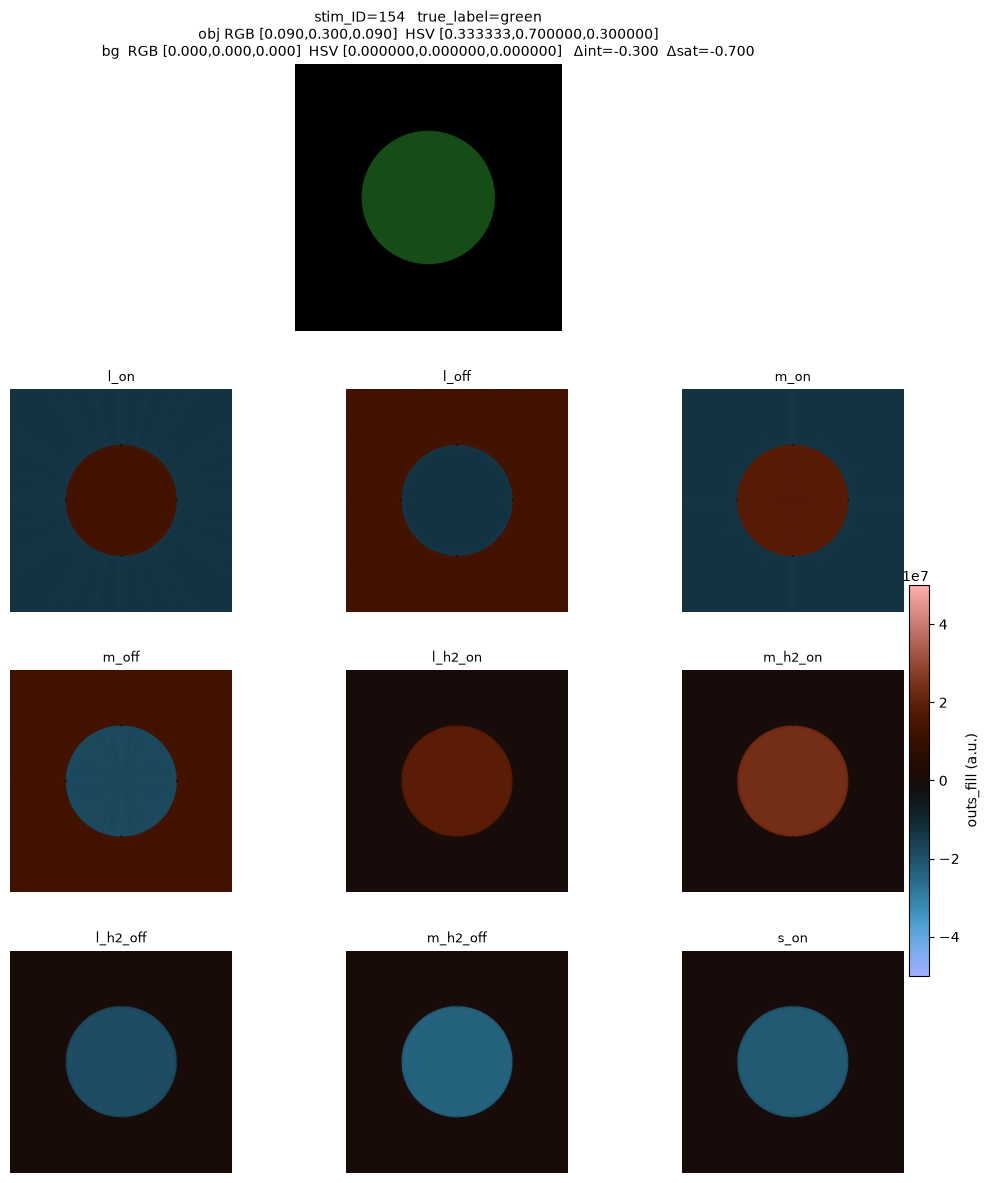

Index 3/8  (stim_ID=154)


In [48]:
# 22. Looking through viewer figures, run:
next_stim()
#prev_stim()
#goto_index(500)
#save_current_png()
